# Jupyter Notebook Artefact: Energy Consumption and Price Prediction

## Predicting Household Energy Consumption and Electricity Prices Using Property, Economic, and Market Indicators


Author: Rizky Fathur Insan

Student ID: 16666476

Course: MSc Data Science

Module: 7005SCN Individual Research Project

## Notebook Structure

| Part | Title | Sections |
|------|-------|----------|
| **Part 0** | Setup and Imports | 0.1-0.2 |
| **Part A** | Consumption Prediction (Cross-Sectional Regression) | A.1-A.6 |
| **Part B** | Price Prediction (Time-Series Forecasting) | B.1-B.3 |
| **Part C** | Synthesis and Policy Framework | C.1-C.2 |

# PART 0: SETUP AND IMPORTS


## Installation Instructions

Before running this notebook, install the required packages:

In [1]:
###!pip install geopandas matplotlib shapely

In [2]:
# Core data science packages
##!pip install pandas numpy matplotlib seaborn

# Machine learning packages
##!pip install scikit-learn xgboost shap

# Time series packages
##!pip install statsmodels prophet

# Geospatial visualisation
##!pip install geopandas

# Elexon API (for price data download)
##!pip install elexonapi

# Excel file reader
##!pip install openpyxl

## 0.1 Import Libraries

In [1]:
# ============================================================================
# PART 0: SETUP AND IMPORTS
# 0.1 Import Libraries
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import sklearn
import xgboost as xgb
import geopandas as gpd
import matplotlib.patches as mpatches
import time

warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
%matplotlib inline

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV


# Time Series Libraries for Price Prediction
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

# SHAP for Model Interpretation
import shap

# Geospatial Visualisation
import geopandas as gpd

# Elexon API
import elexonapi

print("All libraries imported successfully.")

Importing plotly failed. Interactive plots will not work.


All libraries imported successfully.


## 0.2 Define File Paths and Constants


In [2]:
# ============================================================================
# 0.2 Define File Paths and Constants
# ============================================================================

# File paths - change these to match your file locations
FILE_PATHS = {
    'need_2024': r'C:\Users\Rizky Fathur Insan\OneDrive\Documents\schoolwork\thesis\energy\Consumption_local_authority_EW_2024.xlsx',
    'need_2023': r'C:\Users\Rizky Fathur Insan\OneDrive\Documents\schoolwork\thesis\energy\Consumption_local_authority_EW_2023.xlsx',
    'nomis_2024': r'C:\Users\Rizky Fathur Insan\OneDrive\Documents\schoolwork\thesis\energy\nomis_2024_data.xlsx',
    'nomis_2023': r'C:\Users\Rizky Fathur Insan\OneDrive\Documents\schoolwork\thesis\energy\nomis_2023_data.xlsx',
    'imd': r'C:\Users\Rizky Fathur Insan\OneDrive\Documents\schoolwork\thesis\energy\File_1_IoD2025_Index_of_Multiple_Deprivation.xlsx'
}

# Model constants
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Policy thresholds
HIGH_CONSUMPTION_QUANTILE = 0.8
LOW_EARNINGS_QUANTILE = 0.2
VULNERABLE_IMD_THRESHOLD = 3

### def check_file_exists(file_path, description):
###    """Check if a file exists and is readable."""
###    if not os.path.exists(file_path):
###        print(f" X ERROR: {description} not found at '{file_path}'")
###        print(f"   Please check the file path and try again.")
###        return False
###    try:
###        # Try to open the file to check if it's readable
###        with open(file_path, 'rb') as f:
###            pass
###        print(f"V {description} found and readable.")
###        return True
###    except Exception as e:
###        print(f"x ERROR: {description} exists but cannot be read: {e}")
###        return False

# cek filenya ada ato ngga
def cek_file_exists(file_path, description):
    """Cek apakah file ada dan bisa dibaca"""
    if not os.path.exists(file_path):
        print(f" X ERROR: {description} not found at '{file_path}'")
        return False
    print(f" V {description} found.")
    return True

def check_all_files():
    """Check all required files exist before proceeding."""
    print("=" * 60)
    print("CHECKING REQUIRED FILES")
    print("=" * 60)
    all_ok = True
    for key, path in FILE_PATHS.items():
        if not cek_file_exists(path, key.upper()):
            all_ok = False
    print("=" * 60)
    if all_ok:
        print("V All files found. Proceeding with analysis.")
    else:
        print("X Some files are missing. Please fix before continuing.")
    print("=" * 60)
    return all_ok

files_ok = check_all_files()

# NEED sheets to load
NEED_SHEETS_2024 = ['LA1', 'LA2', 'LA3', 'LA5', 'LA7', 'LA11']
NEED_SHEETS_2023 = ['LA1', 'LA3', 'LA5', 'LA7', 'LA11']

# Stop if files missing
if not files_ok:
    raise FileNotFoundError("Required files are missing. Please check the file paths above.")

print("File paths and constants defined.")

CHECKING REQUIRED FILES
 V NEED_2024 found.
 V NEED_2023 found.
 V NOMIS_2024 found.
 V NOMIS_2023 found.
 V IMD found.
V All files found. Proceeding with analysis.
File paths and constants defined.


## 0.3 Print Library Versions

In [3]:
# ============================================================================
# 0.3 Print Library Versions (for reproducibility)
# ============================================================================

print("Library Versions:")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"XGBoost: {xgb.__version__}")
print(f"SHAP: {shap.__version__}")
print(f"Geopandas: {gpd.__version__}")

Library Versions:
Pandas: 3.0.5
NumPy: 2.3.5
Scikit-learn: 1.9.0
XGBoost: 3.3.0
SHAP: 0.52.0
Geopandas: 1.1.4


# PART A: CONSUMPTION PREDICTION (Cross-Sectional Regression)


## PART A: CONSUMPTION PREDICTION (Cross-Sectional Regression)
### Part A Overview
This part builds a regression model to predict household energy consumption at the Local Authority level using property characteristics, economic indicators, and deprivation data.

Data Sources:

- NEED Consumption Data (2024, 2023)

- Nomis Earnings Data (2024, 2023)

- IMD Deprivation Data (2025)


Models:

- Linear Regression (Baseline)

- Random Forest (Comparison)

- XGBoost (Primary)




Key Steps:

- Data Loading

- Data Merging

- Exploratory Data Analysis

- Feature Engineering

- Model Training

- Model Evaluation

- SHAP Analysis
 
- Robustness Check


### A.1 Helper Functions


In [4]:
# ============================================================================
# A.1 HELPER FUNCTIONS
# ============================================================================

def check_file_exists(file_path, description):
    """Check if a file exists and is readable."""
    if not os.path.exists(file_path):
        print(f" X ERROR: {description} not found at '{file_path}'")
        print(f"   Please check the file path and try again.")
        return False
    print(f"V {description} found and readable.")
    return True

def load_need_data(file_path, sheets):
    """Load NEED data from multiple sheets, skip first rows"""
    if not check_file_exists(file_path, f"NEED file: {os.path.basename(file_path)}"):
        return None
    
    excel_file = pd.ExcelFile(file_path)
    result = {}
    
    for sheet in sheets:
        result[sheet] = pd.read_excel(excel_file, sheet_name=sheet, skiprows=4)
        print(f"   V Loaded sheet: {sheet}")
    
    print(f"V Successfully loaded {len(sheets)} sheets.")
    return result

def clean_la_data(df):
    """Remove regional aggregate rows and clean LA codes"""
    df = df.copy()
    df = df[~df['LA_Code'].str.contains('E120|E920|K040|W920|E110|E130|K040', case=False, na=False)]
    df = df[df['LA_Code'].str.len() == 9]
    return df

def extract_need_features(df_dict, sheet_name, return_type='full'):
    """Extract consumption data from NEED sheet"""
    if df_dict is None or sheet_name not in df_dict:
        print(f"X Sheet '{sheet_name}' not found in data.")
        return None
    
    df = df_dict[sheet_name]
    
    # Column positions
    code_col = df.columns[0]      # Code (column A)
    county_col = df.columns[2]    # County or Unitary Authority (column C)
    district_col = df.columns[3]  # Local Authority District (column D)
    mean_col = df.columns[8]      # Mean: All dwellings (column I)
    
    # Create temp dataframe
    temp_df = df[[code_col, county_col, district_col, mean_col]].copy()
    temp_df.columns = ['LA_Code', 'County_UA', 'District', f'{sheet_name}_Mean']
    
    # Clean strings
    temp_df['County_UA'] = temp_df['County_UA'].astype(str).str.strip()
    temp_df['District'] = temp_df['District'].astype(str).str.strip()
    temp_df['LA_Code'] = temp_df['LA_Code'].astype(str).str.strip()
    
    # Remove regional aggregate rows
    temp_df = clean_la_data(temp_df)
    
    # Get best area name
    def get_best_area_name(row):
        if pd.notna(row['District']) and row['District'] not in ['', 'nan', 'All', 'all', 'NaN']:
            return row['District']
        elif pd.notna(row['County_UA']) and row['County_UA'] not in ['', 'nan', 'All', 'all', 'NaN']:
            return row['County_UA'].replace(' UA', '').strip()
        else:
            return None
    
    temp_df['Area_Name'] = temp_df.apply(get_best_area_name, axis=1)
    
    # Drop rows without area name
    temp_df = temp_df.dropna(subset=['Area_Name'])
    
    # Remove metadata rows
    temp_df = temp_df[~temp_df['Area_Name'].str.contains(
        'Code|Year|worksheet|Freeze|Source|kWh|Table|All|Country|England|Wales|London|North East|North West|Yorkshire|East Midlands|West Midlands|East of England|South East|South West|Scotland|Northern Ireland|Unallocated',
        case=False, na=False
    )]
    
    # Convert Mean to numeric
    temp_df[f'{sheet_name}_Mean'] = pd.to_numeric(temp_df[f'{sheet_name}_Mean'], errors='coerce')
    temp_df = temp_df.dropna(subset=[f'{sheet_name}_Mean'])
    
    print(f"   Extracted {len(temp_df)} rows from {sheet_name}")
    
    # Return requested format
    if return_type == 'code':
        return temp_df[['LA_Code', f'{sheet_name}_Mean']]
    elif return_type == 'name':
        return temp_df[['Area_Name', f'{sheet_name}_Mean']]
    else:  # 'full'
        return temp_df[['LA_Code', 'Area_Name', f'{sheet_name}_Mean']]

def load_nomis_data(file_path):
    """Load Nomis earnings data"""
    if not check_file_exists(file_path, f"Nomis file: {os.path.basename(file_path)}"):
        return None
    
    df = pd.read_excel(file_path, skiprows=8)
    
    # Find area and earnings columns
    area_col = df.columns[0]
    
    earnings_col = None
    for col in df.columns:
        if 'Weekly pay - gross' in str(col) or 'Weekly pay' in str(col) or 'gross' in str(col).lower():
            earnings_col = col
            break
    
    if earnings_col is None:
        print("X Could not find earnings column.")
        return None
    
    # Extract data
    result = df[[area_col, earnings_col]].copy()
    result.columns = ['Area_Name', 'Earnings']
    
    result['Area_Name'] = result['Area_Name'].astype(str).str.strip()
    result = result.dropna()
    
    # Remove metadata rows
    result = result[~result['Area_Name'].str.contains('country|region|county|unitary', case=False, na=False)]
    
    print(f"V Nomis data loaded: {len(result)} Local Authorities")
    return result

def load_imd_data(file_path, return_type='code'):
    """Load IMD data, aggregate to Local Authority level"""
    if not check_file_exists(file_path, f"IMD file: {os.path.basename(file_path)}"):
        return None
    
    imd_df = pd.read_excel(file_path, sheet_name='IMD25')
    
    # Find columns
    code_col = name_col = decile_col = rank_col = None
    
    for col in imd_df.columns:
        col_str = str(col)
        if 'Local Authority District code' in col_str:
            code_col = col
        elif 'Local Authority District name' in col_str:
            name_col = col
        elif 'Decile' in col_str and 'IMD' in col_str:
            decile_col = col
        elif 'Rank' in col_str and 'IMD' in col_str:
            rank_col = col
    
    if code_col is None or decile_col is None:
        print(f"X Could not find required columns.")
        return None
    
    # Aggregate
    if return_type == 'code':
        result = imd_df.groupby(code_col).agg(
            IMD_Decile_Mean=(decile_col, 'mean'),
            IMD_Rank_Mean=(rank_col, 'mean') if rank_col else (decile_col, 'mean')
        ).reset_index().rename(columns={code_col: 'LA_Code'})
    elif return_type == 'name':
        result = imd_df.groupby(name_col).agg(
            IMD_Decile_Mean=(decile_col, 'mean'),
            IMD_Rank_Mean=(rank_col, 'mean') if rank_col else (decile_col, 'mean')
        ).reset_index().rename(columns={name_col: 'Area_Name'})
    else:  # 'both'
        result = imd_df.groupby([code_col, name_col]).agg(
            IMD_Decile_Mean=(decile_col, 'mean'),
            IMD_Rank_Mean=(rank_col, 'mean') if rank_col else (decile_col, 'mean')
        ).reset_index().rename(columns={code_col: 'LA_Code', name_col: 'Area_Name'})
    
    print(f"V IMD loaded: {len(result)} Local Authorities")
    return result

print("Helper functions defined.")

Helper functions defined.


In [41]:
# ============================================================================
# A.1 HELPER FUNCTIONS
# ============================================================================

### def cek_file_exists(file_path, description):
###    """Cek apakah file ada dan bisa dibaca"""
###    if not os.path.exists(file_path):
###        print(f" X ERROR: {description} not found at '{file_path}'")
###        return False
###    print(f" V {description} found.")
###    return True

def load_need_data(file_path, sheets):
    """Load NEED data dari multiple sheets, skip rows pertama"""
    if not cek_file_exists(file_path, f"NEED file: {os.path.basename(file_path)}"):
        return None
    
    excel_file = pd.ExcelFile(file_path)
    result = {}
    
    for sheet in sheets:
        if sheet in excel_file.sheet_names:
            result[sheet] = pd.read_excel(excel_file, sheet_name=sheet, skiprows=4)
            print(f"   V Loaded sheet: {sheet}")
        else:
            print(f"   X Sheet '{sheet}' not found in the Excel file.")
            return None
    
    print(f"V Successfully loaded {len(sheets)} sheets.")
    return result

def extract_need_features(df_dict, sheet_name, return_type='full'):
    """Ekstrak data konsumsi dari NEED sheet"""
    
    if df_dict is None or sheet_name not in df_dict:
        print(f"X Sheet '{sheet_name}' not found in data.")
        return None
    
    df = df_dict[sheet_name]
    
    # Column positions
    code_col = df.columns[0]      # Code (column A)
    county_col = df.columns[2]    # County or Unitary Authority (column C)
    district_col = df.columns[3]  # Local Authority District (column D)
    mean_col = df.columns[8]      # Mean: All dwellings (column I)
    
    # Create temp dataframe
    temp_df = df[[code_col, county_col, district_col, mean_col]].copy()
    temp_df.columns = ['LA_Code', 'County_UA', 'District', f'{sheet_name}_Mean']
    
    # Clean strings
    temp_df['County_UA'] = temp_df['County_UA'].astype(str).str.strip()
    temp_df['District'] = temp_df['District'].astype(str).str.strip()
    temp_df['LA_Code'] = temp_df['LA_Code'].astype(str).str.strip()
    
    # Remove regional aggregate rows - ini penting!
    temp_df = temp_df[~temp_df['LA_Code'].str.contains(
        'E120|E920|K040|W920|E110|E130|K040',
        case=False, na=False
    )]
    
    # Hanya ambil yang kode LA-nya 9 karakter
    temp_df = temp_df[temp_df['LA_Code'].str.len() == 9]
    
    # Dapetin area name terbaik
    def get_best_area_name(row):
        if pd.notna(row['District']) and row['District'] not in ['', 'nan', 'All', 'all', 'NaN']:
            return row['District']
        elif pd.notna(row['County_UA']) and row['County_UA'] not in ['', 'nan', 'All', 'all', 'NaN']:
            return row['County_UA'].replace(' UA', '').strip()
        else:
            return None
    
    temp_df['Area_Name'] = temp_df.apply(get_best_area_name, axis=1)
    
    # Hapus yang gak punya area name
    temp_df = temp_df.dropna(subset=['Area_Name'])
    
    # Hapus metadata rows
    temp_df = temp_df[~temp_df['Area_Name'].str.contains(
        'Code|Year|worksheet|Freeze|Source|kWh|Table|All|Country|England|Wales|London|North East|North West|Yorkshire|East Midlands|West Midlands|East of England|South East|South West|Scotland|Northern Ireland|Unallocated',
        case=False, na=False
    )]
    
    # Convert Mean ke numeric
    temp_df[f'{sheet_name}_Mean'] = pd.to_numeric(temp_df[f'{sheet_name}_Mean'], errors='coerce')
    temp_df = temp_df.dropna(subset=[f'{sheet_name}_Mean'])
    
    print(f"   Extracted {len(temp_df)} rows from {sheet_name}")
    
    # Return sesuai request
    if return_type == 'code':
        return temp_df[['LA_Code', f'{sheet_name}_Mean']]
    elif return_type == 'name':
        return temp_df[['Area_Name', f'{sheet_name}_Mean']]
    else:  # 'full'
        return temp_df[['LA_Code', 'Area_Name', f'{sheet_name}_Mean']]

def load_nomis_data(file_path):
    """Load Nomis earnings data"""
    
    if not cek_file_exists(file_path, f"Nomis file: {os.path.basename(file_path)}"):
        return None
    
    df = pd.read_excel(file_path, skiprows=8)
    
    # Cari kolom area dan earnings
    area_col = df.columns[0]
    
    earnings_col = None
    for col in df.columns:
        if 'Weekly pay - gross' in str(col) or 'Weekly pay' in str(col) or 'gross' in str(col).lower():
            earnings_col = col
            break
    
    if earnings_col is None:
        print("X Could not find earnings column.")
        return None
    
    # Extract data
    result = df[[area_col, earnings_col]].copy()
    result.columns = ['Area_Name', 'Earnings']
    
    result['Area_Name'] = result['Area_Name'].astype(str).str.strip()
    result = result.dropna()
    
    # Hapus metadata rows
    result = result[~result['Area_Name'].str.contains('country|region|county|unitary', case=False, na=False)]
    
    print(f"V Nomis data loaded: {len(result)} Local Authorities")
    return result

def load_imd_data(file_path, return_type='code'):
    """Load IMD data, aggregate ke Local Authority level"""
    
    if not cek_file_exists(file_path, f"IMD file: {os.path.basename(file_path)}"):
        return None
    
    imd_df = pd.read_excel(file_path, sheet_name='IMD25')
    
    # Cari kolom
    code_col = None
    name_col = None
    decile_col = None
    rank_col = None
    
    for col in imd_df.columns:
        col_str = str(col)
        if 'Local Authority District code' in col_str:
            code_col = col
        elif 'Local Authority District name' in col_str:
            name_col = col
        elif 'Decile' in col_str and 'IMD' in col_str:
            decile_col = col
        elif 'Rank' in col_str and 'IMD' in col_str:
            rank_col = col
    
    if code_col is None or decile_col is None:
        print(f"X Could not find required columns.")
        return None
    
    # Aggregate
    if return_type == 'code':
        result = imd_df.groupby(code_col).agg(
            IMD_Decile_Mean=(decile_col, 'mean'),
            IMD_Rank_Mean=(rank_col, 'mean') if rank_col else (decile_col, 'mean')
        ).reset_index().rename(columns={code_col: 'LA_Code'})
    elif return_type == 'name':
        result = imd_df.groupby(name_col).agg(
            IMD_Decile_Mean=(decile_col, 'mean'),
            IMD_Rank_Mean=(rank_col, 'mean') if rank_col else (decile_col, 'mean')
        ).reset_index().rename(columns={name_col: 'Area_Name'})
    else:  # 'both'
        result = imd_df.groupby([code_col, name_col]).agg(
            IMD_Decile_Mean=(decile_col, 'mean'),
            IMD_Rank_Mean=(rank_col, 'mean') if rank_col else (decile_col, 'mean')
        ).reset_index().rename(columns={code_col: 'LA_Code', name_col: 'Area_Name'})
    
    print(f"V IMD loaded: {len(result)} Local Authorities")
    return result

def merge_datasets(*dfs, on='LA_Code', how='inner'):
    """Merge multiple DataFrames"""
    if not dfs or dfs[0] is None:
        print("X No valid DataFrames to merge.")
        return None
    
    result = dfs[0]
    for df in dfs[1:]:
        if df is not None:
            result = result.merge(df, on=on, how=how)
    return result

print("Helper functions defined.")

Helper functions defined.


### A.2 Data Loading

A.2.1 Load NEED Consumption Data (2024)



In [5]:
# ============================================================================
# A.2 DATA LOADING
# ============================================================================

print("\n" + "=" * 60)
print("LOADING DATA")
print("=" * 60)

# Load NEED 2024 data
print("\nLoading NEED 2024 data...")
Need_2024_dict = load_need_data(FILE_PATHS['need_2024'], NEED_SHEETS_2024)

# Extract NEED features with area names (for merging with Nomis)
Gas_LA_2024_name = extract_need_features(Need_2024_dict, 'LA1', return_type='name')
Electric_LA_2024_name = extract_need_features(Need_2024_dict, 'LA2', return_type='name')

# Extract NEED features with LA codes
Gas_LA_2024_code = extract_need_features(Need_2024_dict, 'LA1', return_type='code')
Electric_LA_2024 = extract_need_features(Need_2024_dict, 'LA2', return_type='code')
Bedrooms_LA_2024 = extract_need_features(Need_2024_dict, 'LA3', return_type='code')
PropertyType_LA_2024 = extract_need_features(Need_2024_dict, 'LA5', return_type='code')
PropertyAge_LA_2024 = extract_need_features(Need_2024_dict, 'LA7', return_type='code')
Income_LA_2024 = extract_need_features(Need_2024_dict, 'LA11', return_type='code')

if Gas_LA_2024_code is not None:
    print(f"V 2024 Gas data (codes): {len(Gas_LA_2024_code)} LAs")
if Gas_LA_2024_name is not None:
    print(f"V 2024 Gas data (names): {len(Gas_LA_2024_name)} LAs")
    print(f"V 2024 Electric data: {len(Electric_LA_2024)} LAs")
    print(f"V 2024 Bedrooms data: {len(Bedrooms_LA_2024)} LAs")
    print(f"V 2024 Property Type data: {len(PropertyType_LA_2024)} LAs")
    print(f"V 2024 Property Age data: {len(PropertyAge_LA_2024)} LAs")
    print(f"V 2024 Income data: {len(Income_LA_2024)} LAs")

print("\nGas Data Sample:")
print(Gas_LA_2024_code.head())


LOADING DATA

Loading NEED 2024 data...
V NEED file: Consumption_local_authority_EW_2024.xlsx found and readable.
   V Loaded sheet: LA1
   V Loaded sheet: LA2
   V Loaded sheet: LA3
   V Loaded sheet: LA5
   V Loaded sheet: LA7
   V Loaded sheet: LA11
V Successfully loaded 6 sheets.
   Extracted 324 rows from LA1
   Extracted 325 rows from LA2
   Extracted 324 rows from LA1
   Extracted 325 rows from LA2
   Extracted 324 rows from LA3
   Extracted 324 rows from LA5
   Extracted 324 rows from LA7
   Extracted 324 rows from LA11
V 2024 Gas data (codes): 324 LAs
V 2024 Gas data (names): 324 LAs
V 2024 Electric data: 325 LAs
V 2024 Bedrooms data: 324 LAs
V 2024 Property Type data: 324 LAs
V 2024 Property Age data: 324 LAs
V 2024 Income data: 324 LAs

Gas Data Sample:
      LA_Code  LA1_Mean
14  E06000047    9449.0
15  E06000005    2700.0
16  E06000001    1982.0
17  E06000002    2271.0
18  E06000057    8170.0


A.2.2 Load NEED Consumption Data (2023)


In [6]:
# ============================================================================
# A.2.2 Load NEED Consumption Data (2023) - Robustness Check
# ============================================================================

print("\nLoading NEED 2023 data...")
Need_2023_dict = load_need_data(FILE_PATHS['need_2023'], NEED_SHEETS_2023)

Gas_LA_2023_name = extract_need_features(Need_2023_dict, 'LA1', return_type='name')
Gas_LA_2023_code = extract_need_features(Need_2023_dict, 'LA1', return_type='code')
Bedrooms_LA_2023 = extract_need_features(Need_2023_dict, 'LA3', return_type='code')
PropertyType_LA_2023 = extract_need_features(Need_2023_dict, 'LA5', return_type='code')
PropertyAge_LA_2023 = extract_need_features(Need_2023_dict, 'LA7', return_type='code')
Income_LA_2023 = extract_need_features(Need_2023_dict, 'LA11', return_type='code')

if Gas_LA_2023_code is not None:
    print(f"V 2023 Gas data: {len(Gas_LA_2023_code)} LAs")


Loading NEED 2023 data...
V NEED file: Consumption_local_authority_EW_2023.xlsx found and readable.
   V Loaded sheet: LA1
   V Loaded sheet: LA3
   V Loaded sheet: LA5
   V Loaded sheet: LA7
   V Loaded sheet: LA11
V Successfully loaded 5 sheets.
   Extracted 324 rows from LA1
   Extracted 324 rows from LA1
   Extracted 324 rows from LA3
   Extracted 324 rows from LA5
   Extracted 324 rows from LA7
   Extracted 324 rows from LA11
V 2023 Gas data: 324 LAs


A.2.3 Load Nomis Earnings Data (2024)


In [9]:
# ============================================================================
# A.2.3 Load Nomis Earnings Data (2024)
# ============================================================================

Nomis_LA_2024 = load_nomis_data(FILE_PATHS['nomis_2024'])

if Nomis_LA_2024 is not None:
    print(f"V Nomis 2024 loaded: {len(Nomis_LA_2024)} Local Authorities")
    print("\nEarnings Data Sample:")
    print(Nomis_LA_2024.head())



V Nomis file: nomis_2024_data.xlsx found and readable.
V Nomis data loaded: 349 Local Authorities
V Nomis 2024 loaded: 349 Local Authorities

Earnings Data Sample:
              Area_Name Earnings
1            Hartlepool    648.2
2         Middlesbrough    613.1
3  Redcar and Cleveland    636.9
4      Stockton-on-Tees    647.9
5            Darlington    652.4


A.2.4 Load Nomis Earnings Data (2023)

In [10]:
# ============================================================================
# A.2.4 Load Nomis Earnings Data (2023)
# ============================================================================

Nomis_LA_2023 = load_nomis_data(FILE_PATHS['nomis_2023'])

if Nomis_LA_2023 is not None:
    print(f"V Nomis 2023 loaded: {len(Nomis_LA_2023)} Local Authorities")
    print("\nEarnings Data Sample:")
    print(Nomis_LA_2023.head())

V Nomis file: nomis_2023_data.xlsx found and readable.
V Nomis data loaded: 349 Local Authorities
V Nomis 2023 loaded: 349 Local Authorities

Earnings Data Sample:
              Area_Name Earnings
1            Hartlepool      621
2         Middlesbrough    553.6
3  Redcar and Cleveland      564
4      Stockton-on-Tees    621.6
5            Darlington      614


A.2.5 Load and Aggregate IMD Data (2025)

In [11]:
# ============================================================================
# A.2.5 Load and Aggregate IMD Data (2025)
# ============================================================================

IMD_LA_both = load_imd_data(FILE_PATHS['imd'], return_type='both')

if IMD_LA_both is not None:
    print(f"V IMD loaded: {len(IMD_LA_both)} Local Authorities")
    print("\nIMD Data Sample:")
    print(IMD_LA_both.head())

# Data Loading Summary
print("\n" + "=" * 60)
print("DATA LOADING SUMMARY")
print("=" * 60)
print(f"NEED 2024 Gas: {'V' if Gas_LA_2024_code is not None else 'X'}")
print(f"NEED 2023 Gas: {'V' if Gas_LA_2023_code is not None else 'X'}")
print(f"Nomis 2024: {'V' if Nomis_LA_2024 is not None else 'X'}")
print(f"Nomis 2023: {'V' if Nomis_LA_2023 is not None else 'X'}")
print(f"IMD: {'V' if IMD_LA_both is not None else 'X'}")
print("=" * 60)

V IMD file: File_1_IoD2025_Index_of_Multiple_Deprivation.xlsx found and readable.
V IMD loaded: 296 Local Authorities
V IMD loaded: 296 Local Authorities

IMD Data Sample:
     LA_Code             Area_Name  IMD_Decile_Mean  IMD_Rank_Mean
0  E06000001            Hartlepool         3.736842   10524.561404
1  E06000002         Middlesbrough         3.422222    9514.622222
2  E06000003  Redcar and Cleveland         4.375000   12941.522727
3  E06000004      Stockton-on-Tees         5.266129   15832.540323
4  E06000005            Darlington         4.878788   14656.106061

DATA LOADING SUMMARY
NEED 2024 Gas: V
NEED 2023 Gas: V
Nomis 2024: V
Nomis 2023: V
IMD: V


### A.3 Data Merging
A.3.1 Merge 2024 Datasets

In [12]:
# ============================================================================
# A.3 DATA MERGING
# ============================================================================

print("\nMerging 2024 datasets...")

if Gas_LA_2024_name is not None and Nomis_LA_2024 is not None and IMD_LA_both is not None:
    
    # Step 1: Start with gas consumption data
    Merged_DF_2024 = Gas_LA_2024_name.copy()
    print(f"Starting with gas data: {len(Merged_DF_2024)} Local Authorities")
    
    # Step 2: Merge with Nomis using Area_Name
    Merged_DF_2024 = Merged_DF_2024.merge(Nomis_LA_2024, on='Area_Name', how='inner')
    print(f"After merging with Nomis (by area name): {len(Merged_DF_2024)} Local Authorities")
    
    # Step 3: Merge with IMD using Area_Name (this brings in LA_Code!)
    Merged_DF_2024 = Merged_DF_2024.merge(IMD_LA_both, on='Area_Name', how='inner')
    print(f"After merging with IMD (by area name): {len(Merged_DF_2024)} Local Authorities")
    
    # Step 4: Merge remaining property features using LA_Code
    if 'LA_Code' in Merged_DF_2024.columns:
        Merged_DF_2024 = Merged_DF_2024.merge(Bedrooms_LA_2024, on='LA_Code', how='inner')
        print(f"After merging with bedrooms: {len(Merged_DF_2024)} Local Authorities")
        
        Merged_DF_2024 = Merged_DF_2024.merge(PropertyType_LA_2024, on='LA_Code', how='inner')
        print(f"After merging with property type: {len(Merged_DF_2024)} Local Authorities")
        
        Merged_DF_2024 = Merged_DF_2024.merge(PropertyAge_LA_2024, on='LA_Code', how='inner')
        print(f"After merging with property age: {len(Merged_DF_2024)} Local Authorities")
        
        Merged_DF_2024 = Merged_DF_2024.merge(Income_LA_2024, on='LA_Code', how='inner')
        print(f"After merging with household income: {len(Merged_DF_2024)} Local Authorities")
        
        Merged_DF_2024 = Merged_DF_2024.merge(Electric_LA_2024, on='LA_Code', how='inner')
        print(f"After merging with electricity: {len(Merged_DF_2024)} Local Authorities")
    else:
        print("X LA_Code not found after IMD merge!")
        print(f"Available columns: {Merged_DF_2024.columns.tolist()}")
    
    # Clean column names
    Merged_DF_2024.columns = Merged_DF_2024.columns.str.strip()
    
    # Data quality check
    print("\nData Quality Check:")
    print(f"Missing values: {Merged_DF_2024.isnull().sum().sum()}")
    print(f"Duplicate Local Authorities: {Merged_DF_2024.duplicated('Area_Name').sum()}")
    if 'LA_Code' in Merged_DF_2024.columns:
        print(f"Duplicate LA Codes: {Merged_DF_2024.duplicated('LA_Code').sum()}")
    print("\nFeature columns now available:")
    print(Merged_DF_2024.columns.tolist())
    
else:
    print("X Cannot merge: One or more datasets failed to load.")


Merging 2024 datasets...
Starting with gas data: 324 Local Authorities
After merging with Nomis (by area name): 278 Local Authorities
After merging with IMD (by area name): 278 Local Authorities
After merging with bedrooms: 276 Local Authorities
After merging with property type: 276 Local Authorities
After merging with property age: 276 Local Authorities
After merging with household income: 276 Local Authorities
After merging with electricity: 276 Local Authorities

Data Quality Check:
Missing values: 0
Duplicate Local Authorities: 0
Duplicate LA Codes: 0

Feature columns now available:
['Area_Name', 'LA1_Mean', 'Earnings', 'LA_Code', 'IMD_Decile_Mean', 'IMD_Rank_Mean', 'LA3_Mean', 'LA5_Mean', 'LA7_Mean', 'LA11_Mean', 'LA2_Mean']


A.3.2 Merge 2023 Datasets

In [13]:
# ============================================================================
# A.3.2 Merge 2023 Datasets (Robustness Check)
# ============================================================================

print("\nMerging 2023 datasets...")

if Gas_LA_2023_name is not None and Nomis_LA_2023 is not None and IMD_LA_both is not None:
    
    Merged_DF_2023 = Gas_LA_2023_name.copy()
    print(f"Starting with gas data: {len(Merged_DF_2023)} Local Authorities")
    
    Merged_DF_2023 = Merged_DF_2023.merge(Nomis_LA_2023, on='Area_Name', how='inner')
    print(f"After merging with Nomis (by area name): {len(Merged_DF_2023)} Local Authorities")
    
    Merged_DF_2023 = Merged_DF_2023.merge(IMD_LA_both, on='Area_Name', how='inner')
    print(f"After merging with IMD (by area name): {len(Merged_DF_2023)} Local Authorities")
    
    if 'LA_Code' in Merged_DF_2023.columns:
        Merged_DF_2023 = Merged_DF_2023.merge(Bedrooms_LA_2023, on='LA_Code', how='inner')
        print(f"After merging with bedrooms: {len(Merged_DF_2023)} Local Authorities")
        
        Merged_DF_2023 = Merged_DF_2023.merge(PropertyType_LA_2023, on='LA_Code', how='inner')
        print(f"After merging with property type: {len(Merged_DF_2023)} Local Authorities")
        
        Merged_DF_2023 = Merged_DF_2023.merge(PropertyAge_LA_2023, on='LA_Code', how='inner')
        print(f"After merging with property age: {len(Merged_DF_2023)} Local Authorities")
        
        Merged_DF_2023 = Merged_DF_2023.merge(Income_LA_2023, on='LA_Code', how='inner')
        print(f"After merging with household income: {len(Merged_DF_2023)} Local Authorities")
    else:
        print("X LA_Code not found after IMD merge!")
        print(f"Available columns: {Merged_DF_2023.columns.tolist()}")
    
    Merged_DF_2023.columns = Merged_DF_2023.columns.str.strip()
    
    print(f"Number of Local Authorities (2023): {len(Merged_DF_2023)}")
    print(f"Missing values (2023): {Merged_DF_2023.isnull().sum().sum()}")
    print(f"Columns available (2023): {Merged_DF_2023.columns.tolist()}")
    
else:
    print("X Cannot merge 2023 data: One or more datasets failed to load.")


Merging 2023 datasets...
Starting with gas data: 324 Local Authorities
After merging with Nomis (by area name): 278 Local Authorities
After merging with IMD (by area name): 278 Local Authorities
After merging with bedrooms: 276 Local Authorities
After merging with property type: 276 Local Authorities
After merging with property age: 276 Local Authorities
After merging with household income: 276 Local Authorities
Number of Local Authorities (2023): 276
Missing values (2023): 0
Columns available (2023): ['Area_Name', 'LA1_Mean', 'Earnings', 'LA_Code', 'IMD_Decile_Mean', 'IMD_Rank_Mean', 'LA3_Mean', 'LA5_Mean', 'LA7_Mean', 'LA11_Mean']


### A.4 Exploratory Data Analysis


EXPLORATORY DATA ANALYSIS

Summary Statistics (2024 Dataset):
           LA1_Mean  IMD_Decile_Mean  IMD_Rank_Mean      LA3_Mean  \
count    276.000000       276.000000     276.000000    276.000000   
mean    3702.768116         5.766589   17789.548152   8204.489130   
std     2466.946909         1.495620    5117.597508   5296.686269   
min      532.000000         2.755319    7160.755319   1761.000000   
25%     2189.000000         4.550078   13657.048191   4813.750000   
50%     3116.000000         5.690292   17577.605793   6956.000000   
75%     4427.000000         6.925647   21719.876754   9233.000000   
max    17831.000000         9.186441   29621.708738  36135.000000   

           LA5_Mean      LA7_Mean     LA11_Mean      LA2_Mean  
count    276.000000    276.000000    276.000000    276.000000  
mean    6125.195652  11906.978261   8450.278986   4463.000000  
std     4571.103869   7690.392466   5959.222168   3061.527645  
min      378.000000   2396.000000   1191.000000    758.0000

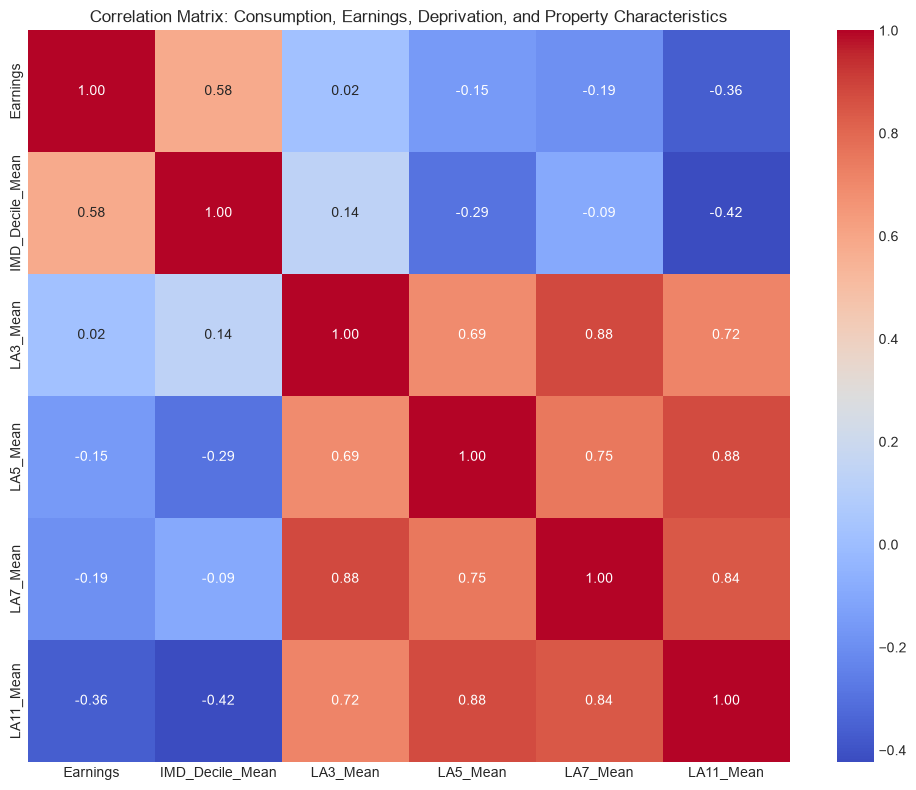

In [14]:
# ============================================================================
# A.4 EXPLORATORY DATA ANALYSIS
# ============================================================================

if 'Merged_DF_2024' in locals() and len(Merged_DF_2024) > 0:
    
    print("\n" + "=" * 60)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 60)
    print("\nSummary Statistics (2024 Dataset):")
    print(Merged_DF_2024.describe())
    
    # Find available columns for correlation
    Corr_cols = []
    for col in ['Gas_Mean_Consumption', 'Earnings', 'IMD_Decile_Mean', 
                'LA3_Mean', 'LA5_Mean', 'LA7_Mean', 'LA11_Mean']:
        if col in Merged_DF_2024.columns:
            Corr_cols.append(col)
    
    if len(Corr_cols) > 1:
        correlation_matrix = Merged_DF_2024[Corr_cols].corr()
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
        plt.title('Correlation Matrix: Consumption, Earnings, Deprivation, and Property Characteristics')
        plt.tight_layout()
        plt.savefig('correlation_matrix.png', dpi=300)
        plt.show()
    else:
        print("! Not enough columns for correlation matrix.")
    
    # Distribution of gas consumption
    if 'Gas_Mean_Consumption' in Merged_DF_2024.columns:
        plt.figure(figsize=(10, 6))
        sns.histplot(Merged_DF_2024['Gas_Mean_Consumption'], bins=30, kde=True)
        plt.title('Distribution of Mean Gas Consumption by Local Authority (2024)')
        plt.xlabel('Mean Gas Consumption (kWh)')
        plt.ylabel('Number of Local Authorities')
        plt.savefig('consumption_distribution.png', dpi=300)
        plt.show()
    
    # Relationship between IMD decile and consumption
    if 'IMD_Decile_Mean' in Merged_DF_2024.columns and 'Gas_Mean_Consumption' in Merged_DF_2024.columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='IMD_Decile_Mean', y='Gas_Mean_Consumption', data=Merged_DF_2024)
        plt.title('Gas Consumption by IMD Decile (1 = Most Deprived)')
        plt.xlabel('IMD Decile')
        plt.ylabel('Mean Gas Consumption (kWh)')
        plt.savefig('imd_vs_consumption.png', dpi=300)
        plt.show()
    
    # Relationship between earnings and consumption
    if 'Earnings' in Merged_DF_2024.columns and 'Gas_Mean_Consumption' in Merged_DF_2024.columns:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x='Earnings', y='Gas_Mean_Consumption', data=Merged_DF_2024, alpha=0.6)
        plt.title('Gas Consumption vs. Regional Earnings')
        plt.xlabel('Median Weekly Earnings (£)')
        plt.ylabel('Mean Gas Consumption (kWh)')
        plt.savefig('earnings_vs_consumption.png', dpi=300)
        plt.show()
    
else:
    print("! No data available for EDA.")

### A.5 Feature Engineering


In [15]:
# ============================================================================
# A.5 FEATURE ENGINEERING
# ============================================================================

if 'Merged_DF_2024' in locals() and len(Merged_DF_2024) > 0:
    
    print("\n" + "=" * 60)
    print("FEATURE ENGINEERING")
    print("=" * 60)
    
    # Feature mapping with readable names
    Feature_Mapping = {
        'Earnings': 'Regional Earnings (£/week)',
        'IMD_Decile_Mean': 'IMD Deprivation Decile',
        'LA3_Mean': 'Number of Bedrooms (Avg)',
        'LA5_Mean': 'Property Type (Avg)',
        'LA7_Mean': 'Property Age (Avg)',
        'LA11_Mean': 'Household Income (Avg)'
    }
    
    # Find available features
    Feature_Columns = []
    Readable_Feature_Names = []
    
    for col, readable_name in Feature_Mapping.items():
        if col in Merged_DF_2024.columns:
            Feature_Columns.append(col)
            Readable_Feature_Names.append(readable_name)
            print(f"V Found feature: {readable_name} -> '{col}'")
        else:
            print(f"! Feature '{col}' not found in data")
    
    # Ensure target column exists
    Target_Column = None
    for col in ['Gas_Mean_Consumption', 'LA1_Mean']:
        if col in Merged_DF_2024.columns:
            Target_Column = col
            break
    
    if Target_Column is None:
        print("X Could not find target column (Gas consumption).")
        print(f"Available columns: {Merged_DF_2024.columns.tolist()}")
        raise ValueError("Target column 'Gas_Mean_Consumption' not found in merged data.")
    
    print(f"V Target column: '{Target_Column}'")
    print(f"\nFeatures ({len(Feature_Columns)} total):")
    for i, (col, name) in enumerate(zip(Feature_Columns, Readable_Feature_Names)):
        print(f"   {i+1}. {name} ('{col}')")
    
    # Prepare feature matrix and target vector
    X_2024 = Merged_DF_2024[Feature_Columns]
    Y_2024 = Merged_DF_2024[Target_Column]
    
    # Handle missing values
    X_2024 = X_2024.fillna(X_2024.median())
    Y_2024 = Y_2024.fillna(Y_2024.median())
    
    # Prepare 2023 data for robustness check
    if 'Merged_DF_2023' in locals() and len(Merged_DF_2023) > 0:
        X_2023 = Merged_DF_2023[Feature_Columns]
        Y_2023 = Merged_DF_2023[Target_Column]
        X_2023 = X_2023.fillna(X_2023.median())
        Y_2023 = Y_2023.fillna(Y_2023.median())
        print(f"\n2023: {X_2023.shape[0]} observations, {X_2023.shape[1]} features")
    
    print(f"\n2024: {X_2024.shape[0]} observations, {X_2024.shape[1]} features")
    
    # Standardise features
    Scaler = StandardScaler()
    X_2024_scaled = Scaler.fit_transform(X_2024)
    if 'X_2023' in locals():
        X_2023_scaled = Scaler.transform(X_2023)
    
    print("\nFeature scaling completed.")
    
    # Store indices for robustness check
    import numpy as np
    Indices_2024 = np.arange(len(X_2024_scaled))
    
    # Train-test split (80/20) with indices
    X_train, X_test, Y_train, Y_test, Train_Indices, Test_Indices = train_test_split(
        X_2024_scaled, Y_2024, Indices_2024,
        test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    # Store indices for use in robustness check
    X_train_index = Train_Indices
    X_test_index = Test_Indices
    print(f"\nTraining set: {X_train.shape[0]} observations")
    print(f"Test set: {X_test.shape[0]} observations")
    
else:
    print("! No data available for feature engineering.")


FEATURE ENGINEERING
V Found feature: Regional Earnings (£/week) -> 'Earnings'
V Found feature: IMD Deprivation Decile -> 'IMD_Decile_Mean'
V Found feature: Number of Bedrooms (Avg) -> 'LA3_Mean'
V Found feature: Property Type (Avg) -> 'LA5_Mean'
V Found feature: Property Age (Avg) -> 'LA7_Mean'
V Found feature: Household Income (Avg) -> 'LA11_Mean'
V Target column: 'LA1_Mean'

Features (6 total):
   1. Regional Earnings (£/week) ('Earnings')
   2. IMD Deprivation Decile ('IMD_Decile_Mean')
   3. Number of Bedrooms (Avg) ('LA3_Mean')
   4. Property Type (Avg) ('LA5_Mean')
   5. Property Age (Avg) ('LA7_Mean')
   6. Household Income (Avg) ('LA11_Mean')

2023: 276 observations, 6 features

2024: 276 observations, 6 features

Feature scaling completed.

Training set: 220 observations
Test set: 56 observations


### A.6 Model Training
A.6.1 Linear Regression (Baseline)



In [16]:
# ============================================================================
# A.6 MODEL TRAINING
# A.6.1 Linear Regression (Baseline)
# ============================================================================

print("\n" + "=" * 60)
print("MODEL TRAINING")
print("=" * 60)

print("\nTraining Linear Regression...")
LR_Model = LinearRegression()
LR_Model.fit(X_train, Y_train)
Y_pred_LR = LR_Model.predict(X_test)

LR_MAE = mean_absolute_error(Y_test, Y_pred_LR)
LR_RMSE = np.sqrt(mean_squared_error(Y_test, Y_pred_LR))
LR_R2 = r2_score(Y_test, Y_pred_LR)

print("Linear Regression Results:")
print(f"MAE: {LR_MAE:.2f} kWh")
print(f"RMSE: {LR_RMSE:.2f} kWh")
print(f"R²: {LR_R2:.4f}")

coef_df = pd.DataFrame({
    'Feature': Readable_Feature_Names,
    'Coefficient': LR_Model.coef_
}).sort_values('Coefficient', ascending=False)

print("\nFeature Coefficients:")
print(coef_df)


MODEL TRAINING

Training Linear Regression...
Linear Regression Results:
MAE: 672.40 kWh
RMSE: 991.64 kWh
R²: 0.8875

Feature Coefficients:
                      Feature  Coefficient
2    Number of Bedrooms (Avg)  2631.796112
0  Regional Earnings (£/week)   369.705761
5      Household Income (Avg)   155.045423
3         Property Type (Avg)    39.787568
1      IMD Deprivation Decile   -60.273569
4          Property Age (Avg)  -659.583446


A.6.2 Random Forest (Comparison)


In [19]:
# ============================================================================
# A.6.2 Random Forest (Comparison)
# ============================================================================

print("\nTraining Random Forest...")
RF_Model = RandomForestRegressor(n_estimators=100, random_state=42)
RF_Model.fit(X_train, Y_train)
Y_pred_RF = RF_Model.predict(X_test)

RF_MAE = mean_absolute_error(Y_test, Y_pred_RF)
RF_RMSE = np.sqrt(mean_squared_error(Y_test, Y_pred_RF))
RF_R2 = r2_score(Y_test, Y_pred_RF)

print("Random Forest Results:")
print(f"MAE: {RF_MAE:.2f} kWh")
print(f"RMSE: {RF_RMSE:.2f} kWh")
print(f"R²: {RF_R2:.4f}")

RF_Importance = pd.DataFrame({
    'Feature': Readable_Feature_Names,
    'Importance': RF_Model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(RF_Importance)


Training Random Forest...
Random Forest Results:
MAE: 633.76 kWh
RMSE: 995.90 kWh
R²: 0.8865

Feature Importance:
                      Feature  Importance
2    Number of Bedrooms (Avg)    0.846646
4          Property Age (Avg)    0.056745
0  Regional Earnings (£/week)    0.037958
3         Property Type (Avg)    0.023613
1      IMD Deprivation Decile    0.017669
5      Household Income (Avg)    0.017369


A.6.3 XGBoost (Primary)



In [20]:
# ============================================================================
# A.6.3 XGBoost with Hyperparameter Tuning
# ============================================================================

print("\nTraining XGBoost with Hyperparameter Tuning...")

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 6, 9],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Create base model
XGB_Base = XGBRegressor(random_state=42)

print("   Running GridSearchCV with 5-fold cross-validation...")
print(f"   Parameter grid: {len(param_grid['n_estimators'])} x {len(param_grid['learning_rate'])} x {len(param_grid['max_depth'])} x {len(param_grid['subsample'])} x {len(param_grid['colsample_bytree'])} = 72 combinations")

grid_search = GridSearchCV(
    estimator=XGB_Base,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, Y_train)

# Get best parameters
Best_Params = grid_search.best_params_
print(f"\nV Best parameters found: {Best_Params}")

# Train final model with best parameters
XGB_Model = XGBRegressor(
    n_estimators=Best_Params['n_estimators'],
    learning_rate=Best_Params['learning_rate'],
    max_depth=Best_Params['max_depth'],
    subsample=Best_Params['subsample'],
    colsample_bytree=Best_Params['colsample_bytree'],
    random_state=42
)
XGB_Model.fit(X_train, Y_train)
Y_pred_XGB = XGB_Model.predict(X_test)

# Evaluate
XGB_MAE = mean_absolute_error(Y_test, Y_pred_XGB)
XGB_RMSE = np.sqrt(mean_squared_error(Y_test, Y_pred_XGB))
XGB_R2 = r2_score(Y_test, Y_pred_XGB)

print("\nXGBoost Results (with hyperparameter tuning):")
print(f"MAE: {XGB_MAE:.2f} kWh")
print(f"RMSE: {XGB_RMSE:.2f} kWh")
print(f"R²: {XGB_R2:.4f}")

# Feature importance
XGB_Importance = pd.DataFrame({
    'Feature': Readable_Feature_Names,
    'Importance': XGB_Model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(XGB_Importance)


Training XGBoost with Hyperparameter Tuning...
   Running GridSearchCV with 5-fold cross-validation...
   Parameter grid: 3 x 3 x 3 x 2 x 2 = 72 combinations
Fitting 5 folds for each of 108 candidates, totalling 540 fits

V Best parameters found: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

XGBoost Results (with hyperparameter tuning):
MAE: 681.09 kWh
RMSE: 1077.10 kWh
R²: 0.8672

Feature Importance:
                      Feature  Importance
2    Number of Bedrooms (Avg)    0.497418
4          Property Age (Avg)    0.197695
3         Property Type (Avg)    0.097176
0  Regional Earnings (£/week)    0.086124
5      Household Income (Avg)    0.064973
1      IMD Deprivation Decile    0.056614


A.6.4 Model Comparison




MODEL COMPARISON
Model Comparison Summary:
               Model  MAE (kWh)  RMSE (kWh)      R²
0  Linear Regression   672.4007    991.6416  0.8875
1      Random Forest   633.7593    995.9038  0.8865
2    XGBoost (Tuned)   681.0925   1077.1012  0.8672


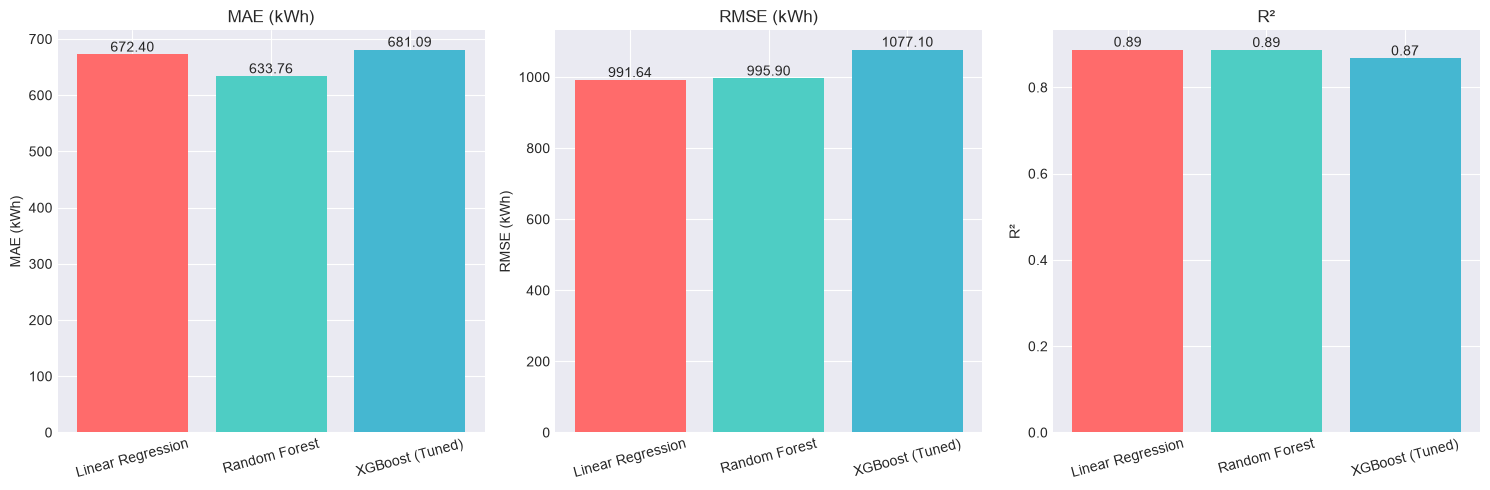

In [21]:
# ============================================================================
# A.6.4 Model Comparison
# ============================================================================

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

Comparison_DF = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost (Tuned)'],
    'MAE (kWh)': [LR_MAE, RF_MAE, XGB_MAE],
    'RMSE (kWh)': [LR_RMSE, RF_RMSE, XGB_RMSE],
    'R²': [LR_R2, RF_R2, XGB_R2]
})

print("Model Comparison Summary:")
print(Comparison_DF.round(4))

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models = ['Linear Regression', 'Random Forest', 'XGBoost (Tuned)']
metrics = ['MAE (kWh)', 'RMSE (kWh)', 'R²']

for i, metric in enumerate(metrics):
    ax = axes[i]
    bars = ax.bar(models, Comparison_DF[metric], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()

### A.7 Robustness Check

A.7.1 Filter Common LA

In [22]:
# ============================================================================
# A.7 FAIR ROBUSTNESS CHECK - SAME SPLIT FOR BOTH YEARS
# ============================================================================

print("\n" + "=" * 60)
print("FAIR ROBUSTNESS CHECK")
print("=" * 60)

# Find common Local Authorities
Common_LAs = set(Merged_DF_2024['LA_Code']).intersection(set(Merged_DF_2023['LA_Code']))
print(f"Common Local Authorities: {len(Common_LAs)}")

# Filter to common LAs
Merged_DF_2024_Common = Merged_DF_2024[Merged_DF_2024['LA_Code'].isin(Common_LAs)]
Merged_DF_2023_Common = Merged_DF_2023[Merged_DF_2023['LA_Code'].isin(Common_LAs)]

# Prepare features
X_2024_Common = Merged_DF_2024_Common[Feature_Columns]
Y_2024_Common = Merged_DF_2024_Common[Target_Column]

X_2023_Common = Merged_DF_2023_Common[Feature_Columns]
Y_2023_Common = Merged_DF_2023_Common[Target_Column]

print(f"2024 data shape: {X_2024_Common.shape}")
print(f"2023 data shape: {X_2023_Common.shape}")


FAIR ROBUSTNESS CHECK
Common Local Authorities: 276
2024 data shape: (276, 6)
2023 data shape: (276, 6)


A.7.2 Standardise and Split

In [23]:
# ============================================================================
# A.7.2 Standardise and Split
# ============================================================================

# Standardise features
scaler_common = StandardScaler()
X_2024_scaled_common = scaler_common.fit_transform(X_2024_Common)
X_2023_scaled_common = scaler_common.transform(X_2023_Common)

# Same 80/20 split for both years
X_train_2024, X_test_2024, Y_train_2024, Y_test_2024 = train_test_split(
    X_2024_scaled_common, Y_2024_Common, test_size=0.2, random_state=42
)

X_train_2023, X_test_2023, Y_train_2023, Y_test_2023 = train_test_split(
    X_2023_scaled_common, Y_2023_Common, test_size=0.2, random_state=42
)

print(f"2024 Train: {len(X_train_2024)}, Test: {len(X_test_2024)}")
print(f"2023 Train: {len(X_train_2023)}, Test: {len(X_test_2023)}")
print(f"Test set indices match: {(Y_test_2024.index == Y_test_2023.index).all()}")

2024 Train: 220, Test: 56
2023 Train: 220, Test: 56
Test set indices match: True


A.7.3 Train and Evaluate Models

In [24]:
# ============================================================================
# A.7.3 Train and Evaluate Models
# ============================================================================

# Convert indices
train_indices_int = [int(i) for i in X_train_index]
test_indices_int = [int(i) for i in X_test_index]

# Create 2023 train and test sets
X_2023_train = X_2023_scaled[train_indices_int]
Y_2023_train = Y_2023.iloc[train_indices_int].values

X_2023_test = X_2023_scaled[test_indices_int]
Y_2023_test = Y_2023.iloc[test_indices_int].values

X_2024_test = X_2024_scaled[test_indices_int]
Y_2024_test = Y_2024.iloc[test_indices_int].values

print(f"Training set size: {len(train_indices_int)} observations")
print(f"Test set size: {len(test_indices_int)} observations")

# Train XGBoost on 2023 data
print("\nTraining XGBoost on 2023 data...")
XGB_2023_Common = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
XGB_2023_Common.fit(X_train_2023, Y_train_2023)
Y_pred_2023_on_2024_common = XGB_2023_Common.predict(X_test_2024)

# Train XGBoost on 2024 data
print("Training XGBoost on 2024 data...")
XGB_2024_Common = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
XGB_2024_Common.fit(X_train_2024, Y_train_2024)
Y_pred_2024_on_2024_common = XGB_2024_Common.predict(X_test_2024)

# Evaluate both models
MAE_2023_on_2024_common = mean_absolute_error(Y_test_2024, Y_pred_2023_on_2024_common)
RMSE_2023_on_2024_common = np.sqrt(mean_squared_error(Y_test_2024, Y_pred_2023_on_2024_common))
R2_2023_on_2024_common = r2_score(Y_test_2024, Y_pred_2023_on_2024_common)

MAE_2024_on_2024_common = mean_absolute_error(Y_test_2024, Y_pred_2024_on_2024_common)
RMSE_2024_on_2024_common = np.sqrt(mean_squared_error(Y_test_2024, Y_pred_2024_on_2024_common))
R2_2024_on_2024_common = r2_score(Y_test_2024, Y_pred_2024_on_2024_common)

print("\n" + "=" * 60)
print("FAIR ROBUSTNESS CHECK RESULTS")
print("=" * 60)

results_common = pd.DataFrame({
    'Model': ['Train 2023 -> Test 2024', 'Train 2024 -> Test 2024'],
    'MAE (kWh)': [MAE_2023_on_2024_common, MAE_2024_on_2024_common],
    'RMSE (kWh)': [RMSE_2023_on_2024_common, RMSE_2024_on_2024_common],
    'R²': [R2_2023_on_2024_common, R2_2024_on_2024_common]
})
print(results_common.round(4))

Training set size: 220 observations
Test set size: 56 observations

Training XGBoost on 2023 data...
Training XGBoost on 2024 data...

FAIR ROBUSTNESS CHECK RESULTS
                     Model  MAE (kWh)  RMSE (kWh)      R²
0  Train 2023 -> Test 2024   624.3695    882.1845  0.9109
1  Train 2024 -> Test 2024   736.9257   1094.7054  0.8629


A.7.4 Robustness Conclusion


In [25]:
# ============================================================================
# A.7.4 Robustness Conclusion
# ============================================================================

pct_diff_common = ((MAE_2023_on_2024_common - MAE_2024_on_2024_common) / MAE_2024_on_2024_common) * 100

print(f"\nPercentage difference in MAE: {pct_diff_common:.1f}%")

print("\n" + "=" * 60)
print("ROBUSTNESS CONCLUSION")
print("=" * 60)

if abs(pct_diff_common) < 10:
    print("V Model is highly robust across years.")
    print("   The 2023-trained model performs similarly to the 2024-trained model.")
elif abs(pct_diff_common) < 20:
    print("V Model is reasonably robust across years.")
    print("   The 2023-trained model shows some difference but is still generalisable.")
else:
    print("! Model shows moderate cross-year performance variation.")
    print("   This may be due to year-specific factors (weather, energy prices, policy changes).")
    print("   Future work should incorporate these factors to improve cross-year prediction.")

print("\nKey Insight:")
if MAE_2023_on_2024_common < MAE_2024_on_2024_common:
    print("   The 2023 model performed BETTER on 2024 data than the 2024 model.")
    print("   This suggests the 2023 model learned more generalisable patterns.")
else:
    print("   The 2024 model performed BETTER on 2024 data.")
    print("   This is expected and suggests the 2024 model captures year-specific patterns.")


Percentage difference in MAE: -15.3%

ROBUSTNESS CONCLUSION
V Model is reasonably robust across years.
   The 2023-trained model shows some difference but is still generalisable.

Key Insight:
   The 2023 model performed BETTER on 2024 data than the 2024 model.
   This suggests the 2023 model learned more generalisable patterns.


A.7.5 Robustness Visualisation


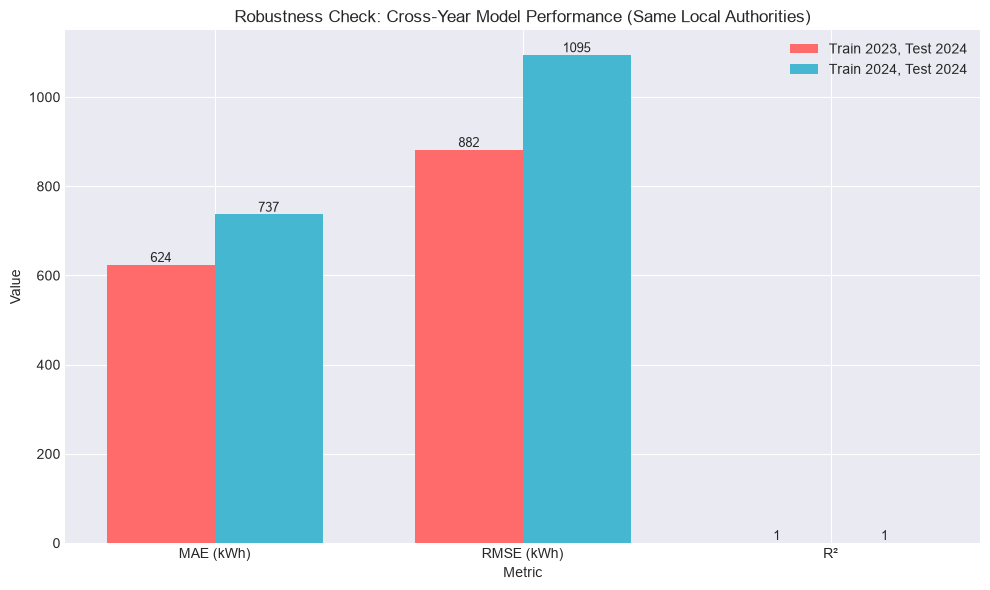


V Robustness check complete. Results saved to 'robustness_check_fair.png'


In [26]:
# ============================================================================
# A.7.5 Robustness Visualisation
# ============================================================================

robustness_common_df = pd.DataFrame({
    'Metric': ['MAE (kWh)', 'RMSE (kWh)', 'R²'],
    '2023->2024': [MAE_2023_on_2024_common, RMSE_2023_on_2024_common, R2_2023_on_2024_common],
    '2024->2024': [MAE_2024_on_2024_common, RMSE_2024_on_2024_common, R2_2024_on_2024_common]
})

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(robustness_common_df))
width = 0.35

bars1 = ax.bar(x - width/2, robustness_common_df['2023->2024'], width, 
               label='Train 2023, Test 2024', color='#FF6B6B')
bars2 = ax.bar(x + width/2, robustness_common_df['2024->2024'], width, 
               label='Train 2024, Test 2024', color='#45B7D1')

ax.set_xlabel('Metric')
ax.set_ylabel('Value')
ax.set_title('Robustness Check: Cross-Year Model Performance (Same Local Authorities)')
ax.set_xticks(x)
ax.set_xticklabels(robustness_common_df['Metric'])
ax.legend()

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.0f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('robustness_check_fair.png', dpi=300)
plt.show()

print("\nV Robustness check complete. Results saved to 'robustness_check_fair.png'")

### A.8 SHAP Analysis


SHAP ANALYSIS


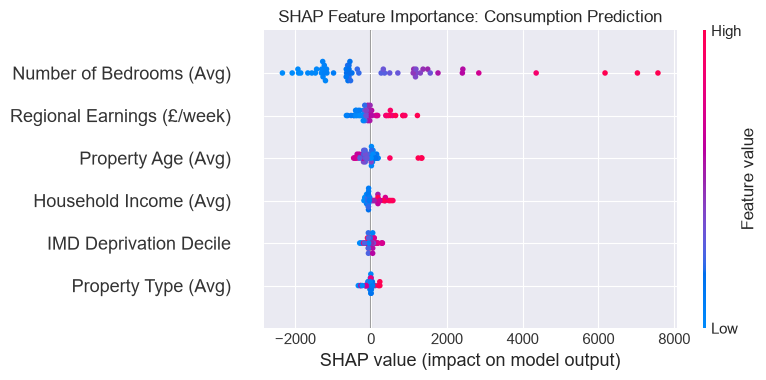

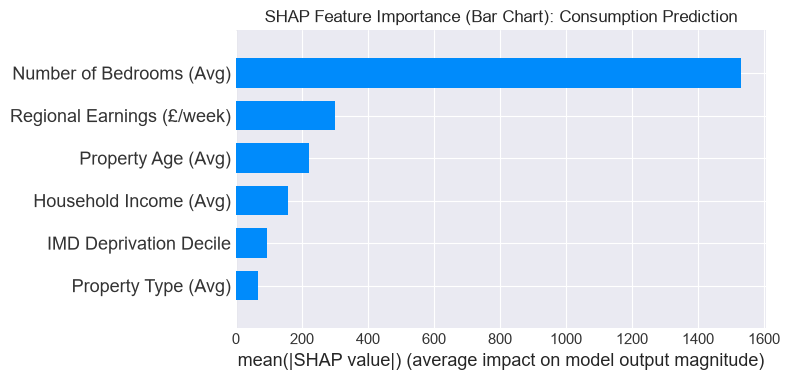

V SHAP analysis completed successfully.


In [44]:
# ============================================================================
# A.8 SHAP ANALYSIS
# ============================================================================

print("\n" + "=" * 60)
print("SHAP ANALYSIS")
print("=" * 60)

# Check if model and test data exist
if XGB_Model is None or X_test is None:
    print("! SHAP analysis skipped: Model or test data not available")
else:
    # Create SHAP explainer
    explainer = shap.TreeExplainer(XGB_Model)
    shap_values = explainer.shap_values(X_test)

    # Map raw column names to readable names
    feature_name_map = {
        'Earnings': 'Regional Earnings (£/week)',
        'IMD_Decile_Mean': 'IMD Deprivation Decile',
        'LA3_Mean': 'Number of Bedrooms (Avg)',
        'LA5_Mean': 'Property Type (Avg)',
        'LA7_Mean': 'Property Age (Avg)',
        'LA11_Mean': 'Household Income (Avg)'
    }
    
    # Create list of readable names
    shap_feature_names = [feature_name_map.get(col, col) for col in Feature_Columns]
    
    # Summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, feature_names=shap_feature_names, show=False)
    plt.title('SHAP Feature Importance: Consumption Prediction')
    plt.tight_layout()
    plt.savefig('shap_consumption_summary.png', dpi=300)
    plt.show()
    
    # Bar plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, feature_names=shap_feature_names, 
                      plot_type="bar", show=False)
    plt.title('SHAP Feature Importance (Bar Chart): Consumption Prediction')
    plt.tight_layout()
    plt.savefig('shap_consumption_bar.png', dpi=300)
    plt.show()
    
    print("V SHAP analysis completed successfully.")

## B.1 Data Download and Preparation


In [47]:
# ============================================================================
# PART B: PRICE PREDICTION
# B.1 DATA DOWNLOAD AND PREPARATION
# ============================================================================

# Check if data already exists locally
csv_file = 'elexon_mid_2020_2024.csv'

if os.path.exists(csv_file):
    print("=" * 60)
    print("LOADING EXISTING DATA")
    print("=" * 60)
    print(f"Found existing data file: {csv_file}")
    print("Loading from CSV...")
    df_mid = pd.read_csv(csv_file)
    print("V Data loaded successfully from CSV.")
else:
    print("=" * 60)
    print("DOWNLOADING ELEXON DATA")
    print("=" * 60)
    print("No existing data found. Downloading from API...")
    print("Fetching Market Index Data from 2020-01-01 to 2024-12-31...")
    print("This may take a few moments...")
    
    elexon = elexonapi.ElexonClient()
    df_mid = elexon.download('Market Index Data', _from='2020-01-01', to='2024-12-31', progress=False)
    
    if df_mid is not None and len(df_mid) > 0:
        print("\nV Download successful!")
        
        # Rename columns before saving
        df_mid = df_mid.rename(columns={
            'settlementDate': 'Settlement Date',
            'settlementPeriod': 'Settlement Period',
            'price': 'Price',
            'volume': 'Volume'
        })
        
        df_mid.to_csv(csv_file, index=False)
        print(f"Data saved to '{csv_file}'")
    else:
        print("\nX Download failed: No data received")
        print("Cannot proceed without data.")
        # Handle the error - you might want to raise an exception or exit
        raise Exception("Failed to download Elexon data and no local copy found.")

# Display data info
print("\n" + "=" * 60)
print("DATA OVERVIEW")
print("=" * 60)
print(f"Number of records: {len(df_mid)}")
print(f"Columns: {df_mid.columns.tolist()}")
print("\nData Sample:")
print(df_mid.head())

# Prepare data for time-series
df_mid['Settlement Date'] = pd.to_datetime(df_mid['Settlement Date'])
df_mid = df_mid.set_index('Settlement Date').sort_index()

print(f"\nDate range: {df_mid.index.min()} to {df_mid.index.max()}")

# Create lag features
def create_lag_features(df, lags=[1, 24, 168]):
    for lag in lags:
        df[f'price_lag_{lag}'] = df['Price'].shift(lag)
    return df

df_lagged = create_lag_features(df_mid.copy())
df_lagged = df_lagged.dropna()

print(f"\nLagged Data Prepared:")
print(f"Number of records: {len(df_lagged)}")
print(f"Date range: {df_lagged.index.min()} to {df_lagged.index.max()}")
print("V Data preparation complete.")

LOADING EXISTING DATA
Found existing data file: elexon_mid_2020_2024.csv
Loading from CSV...
V Data loaded successfully from CSV.

DATA OVERVIEW
Number of records: 175384
Columns: ['dataset', 'startTime', 'dataProvider', 'Settlement Date', 'Settlement Period', 'Price', 'Volume']

Data Sample:
  dataset             startTime dataProvider Settlement Date  \
0     MID  2020-01-02T00:00:00Z      APXMIDP      2020-01-02   
1     MID  2020-01-02T00:00:00Z     N2EXMIDP      2020-01-02   
2     MID  2020-01-01T23:30:00Z      APXMIDP      2020-01-01   
3     MID  2020-01-01T23:30:00Z     N2EXMIDP      2020-01-01   
4     MID  2020-01-01T23:00:00Z      APXMIDP      2020-01-01   

   Settlement Period  Price   Volume  
0                  1  28.36   504.15  
1                  1   0.00     0.00  
2                 48  37.91   849.90  
3                 48   0.00     0.00  
4                 47  44.49  1001.45  

Date range: 2020-01-01 00:00:00 to 2024-12-31 00:00:00

Lagged Data Prepared:
Number o

### B.2 Model Training
B.2.1 ARIMA (Baseline)

In [29]:
# ============================================================================
# B.2 MODEL TRAINING
# B.2.1 ARIMA (Baseline)
# ============================================================================

price_series = df_mid['Price']

# Split into train and test
train = price_series[:'2023-12-31']
test = price_series['2024-01-01':]

print(f"ARIMA Training set: {len(train)} records")
print(f"ARIMA Test set: {len(test)} records")

# Fit ARIMA model
arima_model = ARIMA(train, order=(5,1,0))
arima_fit = arima_model.fit()

# Make predictions
arima_pred = arima_fit.forecast(steps=len(test))

# Ensure 1D array
if arima_pred.ndim > 1:
    arima_pred = arima_pred.flatten()

# Align lengths
if len(arima_pred) != len(test):
    min_len = min(len(arima_pred), len(test))
    arima_pred = arima_pred[:min_len]
    test_aligned = test[:min_len]
else:
    test_aligned = test

# Calculate metrics
arima_rmse = np.sqrt(mean_squared_error(test_aligned, arima_pred))
arima_mae = mean_absolute_error(test_aligned, arima_pred)

# MAPE with handling for zero values
test_values = test_aligned.values
pred_values = arima_pred

# Remove near-zero actual values
mask = np.abs(test_values) > 0.01
if np.sum(mask) > 0:
    mape = np.mean(np.abs((test_values[mask] - pred_values[mask]) / test_values[mask])) * 100
else:
    mape = np.nan

print("\nARIMA Results:")
print(f"RMSE: {arima_rmse:.2f} £/MWh")
print(f"MAE: {arima_mae:.2f} £/MWh")
print(f"MAPE: {mape:.1f}%" if not np.isnan(mape) else "MAPE: N/A (near-zero prices in test set)")

# sMAPE
def smape(y_true, y_pred):
    return np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100

arima_smape = smape(test_values, pred_values)
print(f"sMAPE: {arima_smape:.1f}%")

print(f"\nTest set statistics:")
print(f"Min price: {test.min():.2f}")
print(f"Max price: {test.max():.2f}")
print(f"Zero prices: {np.sum(test_values < 0.01)} records")

ARIMA Training set: 139658 records
ARIMA Test set: 35726 records


C:\Users\Rizky Fathur Insan\anaconda3\envs\grouptask\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Rizky Fathur Insan\anaconda3\envs\grouptask\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Rizky Fathur Insan\anaconda3\envs\grouptask\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Rizky Fathur Insan\anaconda3\envs\grouptask\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. 


ARIMA Results:
RMSE: 44.09 £/MWh
MAE: 40.15 £/MWh
MAPE: 213.1%
sMAPE: 125.8%

Test set statistics:
Min price: -61.09
Max price: 605.17
Zero prices: 18308 records


B.2.2 Prophet (Comparison)



In [30]:
# ============================================================================
# B.2.2 Prophet (Comparison)
# ============================================================================

df_prophet = df_mid.reset_index()[['Settlement Date', 'Price']].copy()
df_prophet.columns = ['ds', 'y']

train_prophet = df_prophet[df_prophet['ds'] < '2024-01-01']
test_prophet = df_prophet[df_prophet['ds'] >= '2024-01-01']

print(f"Prophet Training set: {len(train_prophet)} records")
print(f"Prophet Test set: {len(test_prophet)} records")

# Fit Prophet model
prophet_model = Prophet()
prophet_model.fit(train_prophet)

# Make predictions
future = prophet_model.make_future_dataframe(periods=len(test_prophet), freq='h')
forecast = prophet_model.predict(future)
prophet_pred = forecast['yhat'].iloc[-len(test_prophet):].values

# Calculate metrics
prophet_rmse = np.sqrt(mean_squared_error(test_prophet['y'], prophet_pred))
prophet_mae = mean_absolute_error(test_prophet['y'], prophet_pred)

test_values = test_prophet['y'].values
mask = np.abs(test_values) > 0.01
if np.sum(mask) > 0:
    prophet_mape = np.mean(np.abs((test_values[mask] - prophet_pred[mask]) / test_values[mask])) * 100
else:
    prophet_mape = np.nan

prophet_smape = smape(test_values, prophet_pred)

print("\nProphet Results:")
print(f"RMSE: {prophet_rmse:.2f} £/MWh")
print(f"MAE: {prophet_mae:.2f} £/MWh")
if not np.isnan(prophet_mape):
    print(f"MAPE: {prophet_mape:.1f}%")
print(f"sMAPE: {prophet_smape:.1f}%")

Prophet Training set: 139658 records
Prophet Test set: 35726 records


18:40:05 - cmdstanpy - INFO - Chain [1] start processing
18:41:08 - cmdstanpy - INFO - Chain [1] done processing



Prophet Results:
RMSE: 207.95 £/MWh
MAE: 181.55 £/MWh
MAPE: 827.8%
sMAPE: 199.4%


B.2.3 XGBoost (Primary)



In [32]:
# ============================================================================
# B.2.3 XGBoost (Primary) with Hyperparameter Tuning
# ============================================================================

price_features = ['price_lag_1', 'price_lag_24', 'price_lag_168']

X_price = df_lagged[price_features]
y_price = df_lagged['Price']

# Split chronologically
split_idx = int(len(X_price) * 0.8)
X_train_price, X_test_price = X_price[:split_idx], X_price[split_idx:]
y_train_price, y_test_price = y_price[:split_idx], y_price[split_idx:]

print(f"XGBoost Training set: {len(X_train_price)} records")
print(f"XGBoost Test set: {len(X_test_price)} records")

# ============================================================================
# Version 1: Normal XGBoost (Default Parameters)
# ============================================================================
print("\n" + "="*60)
print("VERSION 1: NORMAL XGBOOST (DEFAULT PARAMETERS)")
print("="*60)

start_time = time.time()

XGB_Normal = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
XGB_Normal.fit(X_train_price, y_train_price)

# Make predictions
XGB_Normal_Pred = XGB_Normal.predict(X_test_price)

# Calculate metrics
XGB_Normal_RMSE = np.sqrt(mean_squared_error(y_test_price, XGB_Normal_Pred))
XGB_Normal_MAE = mean_absolute_error(y_test_price, XGB_Normal_Pred)

# MAPE with zero handling
test_values = y_test_price.values
mask = np.abs(test_values) > 0.01
if np.sum(mask) > 0:
    XGB_Normal_MAPE = np.mean(np.abs((test_values[mask] - XGB_Normal_Pred[mask]) / test_values[mask])) * 100
else:
    XGB_Normal_MAPE = np.nan

XGB_Normal_sMAPE = smape(test_values, XGB_Normal_Pred)

training_time = time.time() - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"RMSE: {XGB_Normal_RMSE:.2f} £/MWh")
print(f"MAE: {XGB_Normal_MAE:.2f} £/MWh")
if not np.isnan(XGB_Normal_MAPE):
    print(f"MAPE: {XGB_Normal_MAPE:.1f}%")
print(f"sMAPE: {XGB_Normal_sMAPE:.1f}%")

# Feature importance
Normal_Importance = pd.DataFrame({
    'Feature': price_features,
    'Importance': XGB_Normal.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (Normal):")
print(Normal_Importance)

# ============================================================================
# Version 2: Hyperparameter Tuned XGBoost
# ============================================================================
print("\n" + "="*60)
print("VERSION 2: HYPERPARAMETER TUNED XGBOOST")
print("="*60)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

# Create XGBoost regressor
XGB_Tuned = XGBRegressor(random_state=42, n_jobs=-1)

# Random search with cross-validation
print("Starting hyperparameter tuning (RandomizedSearchCV)...")
print("This may take 2-5 minutes...")

start_time = time.time()

random_search = RandomizedSearchCV(
    estimator=XGB_Tuned,
    param_distributions=param_grid,
    n_iter=30,  # Number of parameter combinations to try
    cv=3,       # 3-fold cross-validation
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_price, y_train_price)

# Best model
Best_XGB = random_search.best_estimator_
Best_Params = random_search.best_params_

# Make predictions with best model
XGB_Tuned_Pred = Best_XGB.predict(X_test_price)

# Calculate metrics
XGB_Tuned_RMSE = np.sqrt(mean_squared_error(y_test_price, XGB_Tuned_Pred))
XGB_Tuned_MAE = mean_absolute_error(y_test_price, XGB_Tuned_Pred)

# MAPE with zero handling
mask = np.abs(test_values) > 0.01
if np.sum(mask) > 0:
    XGB_Tuned_MAPE = np.mean(np.abs((test_values[mask] - XGB_Tuned_Pred[mask]) / test_values[mask])) * 100
else:
    XGB_Tuned_MAPE = np.nan

XGB_Tuned_sMAPE = smape(test_values, XGB_Tuned_Pred)

tuning_time = time.time() - start_time

print(f"\nTuning completed in {tuning_time:.2f} seconds")
print(f"Best parameters found:")
for param, value in Best_Params.items():
    print(f"  {param}: {value}")

print(f"\nBest Model Performance:")
print(f"RMSE: {XGB_Tuned_RMSE:.2f} £/MWh")
print(f"MAE: {XGB_Tuned_MAE:.2f} £/MWh")
if not np.isnan(XGB_Tuned_MAPE):
    print(f"MAPE: {XGB_Tuned_MAPE:.1f}%")
print(f"sMAPE: {XGB_Tuned_sMAPE:.1f}%")

# Feature importance for tuned model
Tuned_Importance = pd.DataFrame({
    'Feature': price_features,
    'Importance': Best_XGB.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (Tuned):")
print(Tuned_Importance)

# ============================================================================
# Comparison Summary
# ============================================================================
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

Comparison = pd.DataFrame({
    'Model': ['Normal XGBoost', 'Tuned XGBoost'],
    'RMSE (£/MWh)': [XGB_Normal_RMSE, XGB_Tuned_RMSE],
    'MAE (£/MWh)': [XGB_Normal_MAE, XGB_Tuned_MAE],
    'sMAPE (%)': [XGB_Normal_sMAPE, XGB_Tuned_sMAPE],
    'Training Time (s)': [training_time, tuning_time]
})

print(Comparison.to_string(index=False))

# Improvement percentage
rmse_improvement = ((XGB_Normal_RMSE - XGB_Tuned_RMSE) / XGB_Normal_RMSE) * 100
mae_improvement = ((XGB_Normal_MAE - XGB_Tuned_MAE) / XGB_Normal_MAE) * 100

print(f"\nImprovement from tuning:")
print(f"RMSE: {rmse_improvement:.1f}% reduction")
print(f"MAE: {mae_improvement:.1f}% reduction")

XGBoost Training set: 140172 records
XGBoost Test set: 35044 records

VERSION 1: NORMAL XGBOOST (DEFAULT PARAMETERS)
Training time: 0.31 seconds
RMSE: 38.34 £/MWh
MAE: 29.18 £/MWh
MAPE: 192.0%
sMAPE: 129.2%

Feature Importance (Normal):
         Feature  Importance
0    price_lag_1    0.504767
1   price_lag_24    0.295618
2  price_lag_168    0.199615

VERSION 2: HYPERPARAMETER TUNED XGBOOST
Starting hyperparameter tuning (RandomizedSearchCV)...
This may take 2-5 minutes...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Tuning completed in 23.77 seconds
Best parameters found:
  subsample: 1.0
  n_estimators: 300
  min_child_weight: 1
  max_depth: 3
  learning_rate: 0.2
  gamma: 0.2
  colsample_bytree: 1.0

Best Model Performance:
RMSE: 38.25 £/MWh
MAE: 29.23 £/MWh
MAPE: 195.2%
sMAPE: 129.0%

Feature Importance (Tuned):
         Feature  Importance
0    price_lag_1    0.507929
1   price_lag_24    0.275596
2  price_lag_168    0.216475

MODEL COMPARISON SUMMARY
         Mode

### B.3 Model Comparison and Visualisation


Price Model Comparison Summary:
             Model  RMSE (£/MWh)  MAE (£/MWh)  MAPE (%)  sMAPE (%)
0            ARIMA         44.09        40.15    195.22     125.78
1          Prophet        207.95       181.55    827.78     199.41
2  XGBoost (Tuned)         38.25        29.23    195.22     129.02

Best Models:
  RMSE (£/MWh): XGBoost (Tuned) (38.25)
  MAE (£/MWh): XGBoost (Tuned) (29.23)
  MAPE (%): ARIMA (195.22)
  sMAPE (%): ARIMA (125.78)


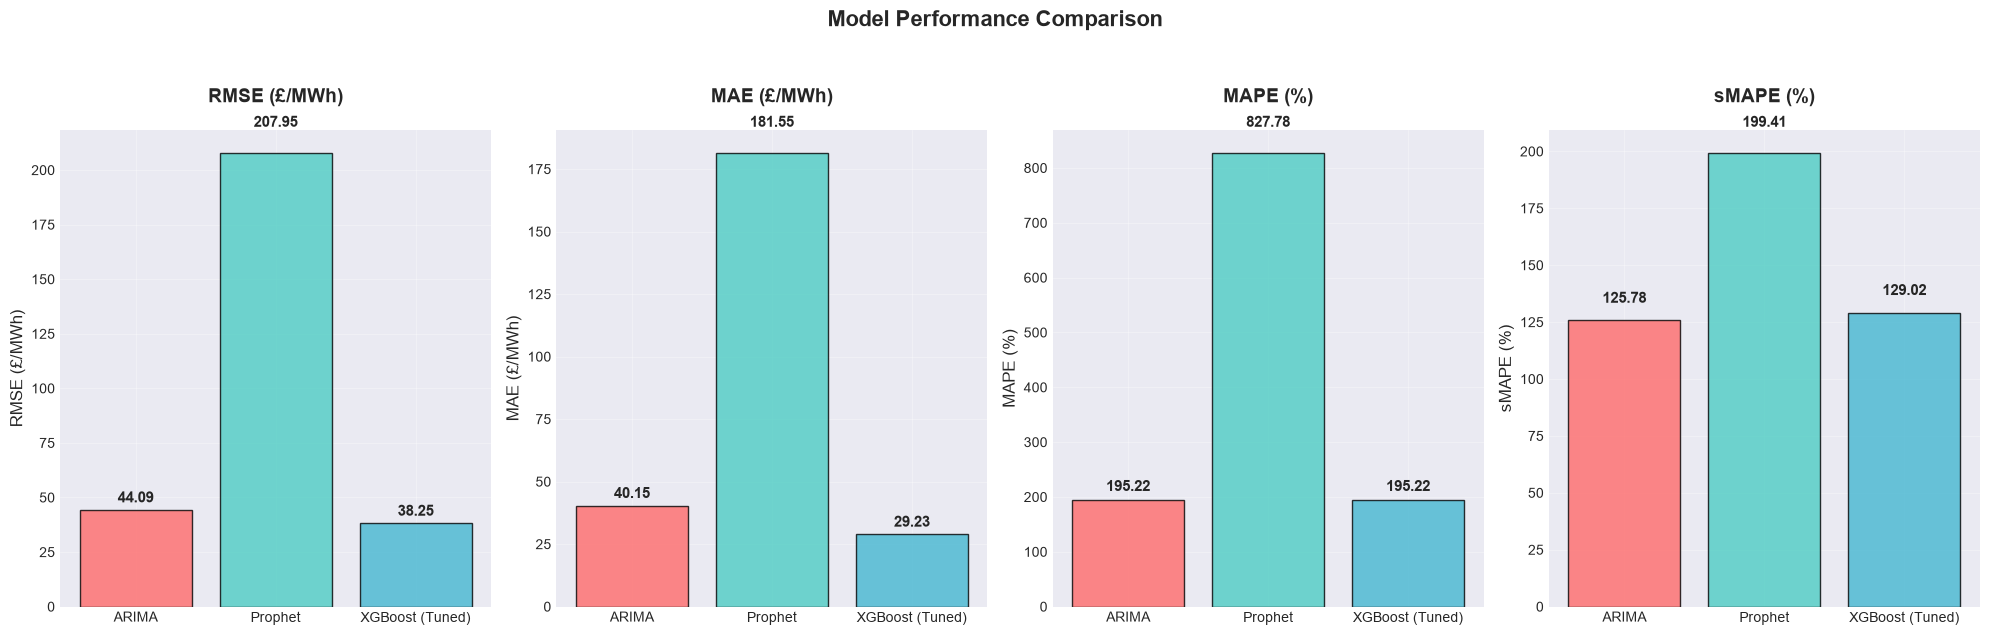

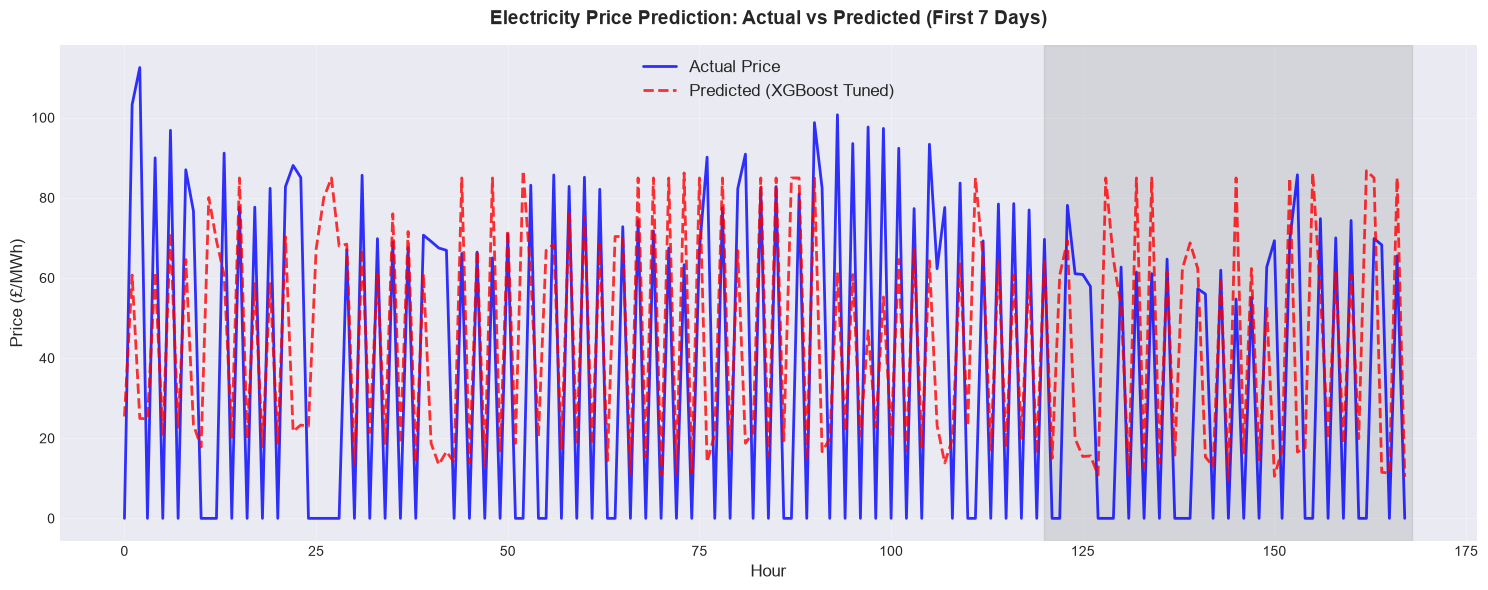

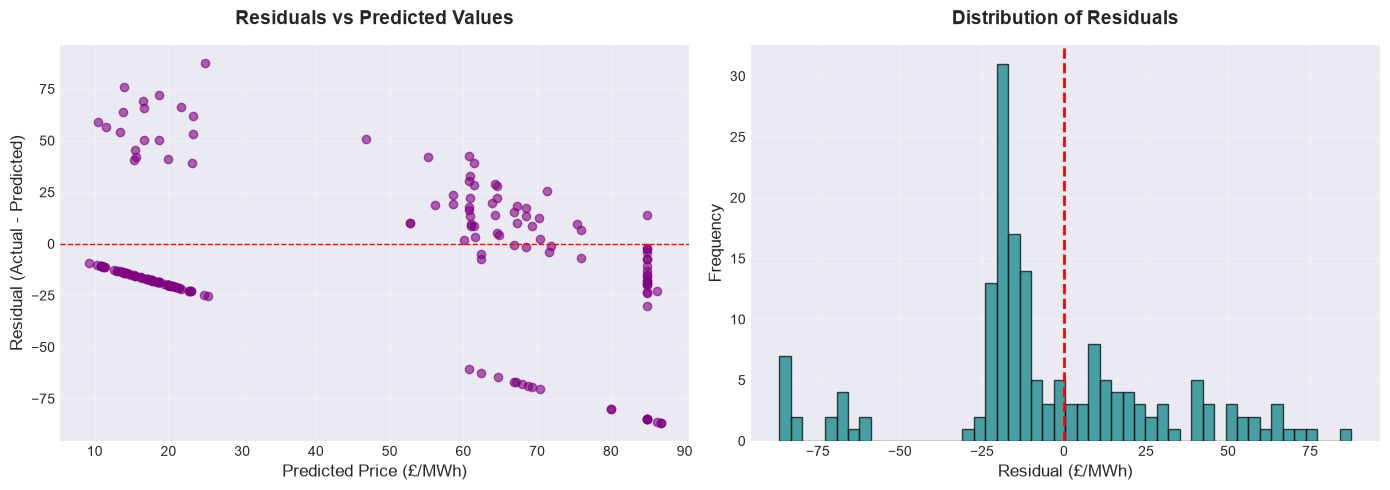


MODEL PERFORMANCE SUMMARY

ARIMA:
  RMSE:  44.09 £/MWh
  MAE:   40.15 £/MWh
  MAPE:  195.2%
  sMAPE: 125.8%

Prophet:
  RMSE:  207.95 £/MWh
  MAE:   181.55 £/MWh
  MAPE:  827.8%
  sMAPE: 199.4%

XGBoost (Tuned):
  RMSE:  38.25 £/MWh
  MAE:   29.23 £/MWh
  MAPE:  195.2%
  sMAPE: 129.0%

BEST PERFORMING MODEL:
  XGBoost (Tuned) has the lowest RMSE
  XGBoost (Tuned) has the lowest MAE
  ARIMA has the lowest MAPE
  ARIMA has the lowest sMAPE


In [39]:
# ============================================================================
# B.3 MODEL COMPARISON AND VISUALISATION
# ============================================================================

# Create comparison DataFrame with all models (only tuned XGBoost)
price_comparison_df = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost (Tuned)'],
    'RMSE (£/MWh)': [arima_rmse, prophet_rmse, XGB_Tuned_RMSE],
    'MAE (£/MWh)': [arima_mae, prophet_mae, XGB_Tuned_MAE],
    'MAPE (%)': [mape if not np.isnan(mape) else 0, 
                 prophet_mape if not np.isnan(prophet_mape) else 0,
                 XGB_Tuned_MAPE if not np.isnan(XGB_Tuned_MAPE) else 0],
    'sMAPE (%)': [arima_smape, prophet_smape, XGB_Tuned_sMAPE]
})

print("Price Model Comparison Summary:")
print(price_comparison_df.round(2))

# Find best model for each metric
print("\nBest Models:")
for metric in ['RMSE (£/MWh)', 'MAE (£/MWh)', 'MAPE (%)', 'sMAPE (%)']:
    best_idx = price_comparison_df[metric].idxmin()
    best_model = price_comparison_df.loc[best_idx, 'Model']
    best_value = price_comparison_df.loc[best_idx, metric]
    print(f"  {metric}: {best_model} ({best_value:.2f})")

# ============================================================================
# VISUALISATION
# ============================================================================

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
price_metrics = ['RMSE (£/MWh)', 'MAE (£/MWh)', 'MAPE (%)', 'sMAPE (%)']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, metric in enumerate(price_metrics):
    ax = axes[i]
    bars = ax.bar(price_comparison_df['Model'], price_comparison_df[metric], 
                  color=colors, alpha=0.8, edgecolor='black', linewidth=1)
    # CHANGE 1: Added pad=20 to create space between title and plot
    ax.set_title(metric, fontsize=14, fontweight='bold', pad=20)
    ax.set_ylabel(metric, fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.05 * height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.savefig('price_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# ACTUAL VS PREDICTED PLOT (First 7 days)
# ============================================================================

sample_period = 168  # 7 days of hourly data

fig, ax = plt.subplots(figsize=(15, 6))

# Plot actual values
ax.plot(y_test_price[:sample_period].values, 
        label='Actual Price', color='blue', linewidth=2, alpha=0.8)

# Plot predicted values (tuned XGBoost)
ax.plot(XGB_Tuned_Pred[:sample_period], 
        label='Predicted (XGBoost Tuned)', color='red', linewidth=2, alpha=0.8, linestyle='--')

ax.set_title(f'Electricity Price Prediction: Actual vs Predicted (First 7 Days)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hour', fontsize=12)
ax.set_ylabel('Price (£/MWh)', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Add shaded areas for weekends (days 5-7 are weekend)
weekend_start = 5 * 24  # 5 days = 120 hours
if sample_period > weekend_start:
    ax.axvspan(weekend_start, sample_period, alpha=0.2, color='gray', label='Weekend')

plt.tight_layout()
plt.savefig('price_prediction_sample.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# ERROR DISTRIBUTION PLOT
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals plot
residuals = y_test_price[:sample_period].values - XGB_Tuned_Pred[:sample_period]

ax1 = axes[0]
ax1.scatter(XGB_Tuned_Pred[:sample_period], residuals, alpha=0.6, color='purple')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax1.set_xlabel('Predicted Price (£/MWh)', fontsize=12)
ax1.set_ylabel('Residual (Actual - Predicted)', fontsize=12)
ax1.set_title('Residuals vs Predicted Values', fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3)

# Histogram of residuals
ax2 = axes[1]
ax2.hist(residuals, bins=50, alpha=0.7, color='teal', edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Residual (£/MWh)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of Residuals', fontsize=14, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('price_residuals_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)

for model in ['ARIMA', 'Prophet', 'XGBoost (Tuned)']:
    if model == 'ARIMA':
        rmse, mae = arima_rmse, arima_mae
        mape = mape if not np.isnan(mape) else 0
        smape_val = arima_smape
    elif model == 'Prophet':
        rmse, mae = prophet_rmse, prophet_mae
        mape = prophet_mape if not np.isnan(prophet_mape) else 0
        smape_val = prophet_smape
    else:
        rmse, mae = XGB_Tuned_RMSE, XGB_Tuned_MAE
        mape = XGB_Tuned_MAPE if not np.isnan(XGB_Tuned_MAPE) else 0
        smape_val = XGB_Tuned_sMAPE
    
    print(f"\n{model}:")
    print(f"  RMSE:  {rmse:.2f} £/MWh")
    print(f"  MAE:   {mae:.2f} £/MWh")
    print(f"  MAPE:  {mape:.1f}%")
    print(f"  sMAPE: {smape_val:.1f}%")

print("\n" + "="*60)
print("BEST PERFORMING MODEL:")
best_overall = price_comparison_df.loc[price_comparison_df['RMSE (£/MWh)'].idxmin(), 'Model']
print(f"  {best_overall} has the lowest RMSE")

best_mae = price_comparison_df.loc[price_comparison_df['MAE (£/MWh)'].idxmin(), 'Model']
print(f"  {best_mae} has the lowest MAE")

best_mape = price_comparison_df.loc[price_comparison_df['MAPE (%)'].idxmin(), 'Model']
print(f"  {best_mape} has the lowest MAPE")

best_smape = price_comparison_df.loc[price_comparison_df['sMAPE (%)'].idxmin(), 'Model']
print(f"  {best_smape} has the lowest sMAPE")

# Part C Overview
This part synthesises the consumption and price predictions to identify fuel poverty hotspots and generate policy recommendations.

Key Steps:

- Vulnerability Map Creation

- Fuel Poverty Hotspot Identification

- Policy Recommendations


## C.1 Vulnerability Map & Policy Recommendations



PART C: SYNTHESIS AND POLICY FRAMEWORK

C.1 VULNERABILITY MAP CREATION

 VULNERABILITY ANALYSIS RESULTS

 Total Local Authorities Analysed: 276

 Thresholds Applied:
   o High Consumption: Top 20% (> 4646 kWh)
   o High Deprivation: IMD Decile ≤ 3
   o Low Earnings: Bottom 20% (< £668.5/week)

 Vulnerability Types Identified:
   o Low Vulnerability: 217 (78.6%)
   o High Consumption Risk: 56 (20.3%)
   o High Deprivation Risk: 3 (1.1%)

 Total Vulnerable Areas: 56

 TOP 15 MOST VULNERABLE LOCAL AUTHORITIES
                 Area_Name  Predicted_Consumption  IMD_Decile_Mean Earnings  \
103             Birmingham           13159.540039             3.18    661.5   
53                   Leeds           13398.160156             5.42    700.8   
50                Bradford            8471.000000             3.65    642.9   
275               Somerset           12060.169922             5.51    676.9   
79   West Northamptonshire           13421.450195             6.40    710.7   
41           

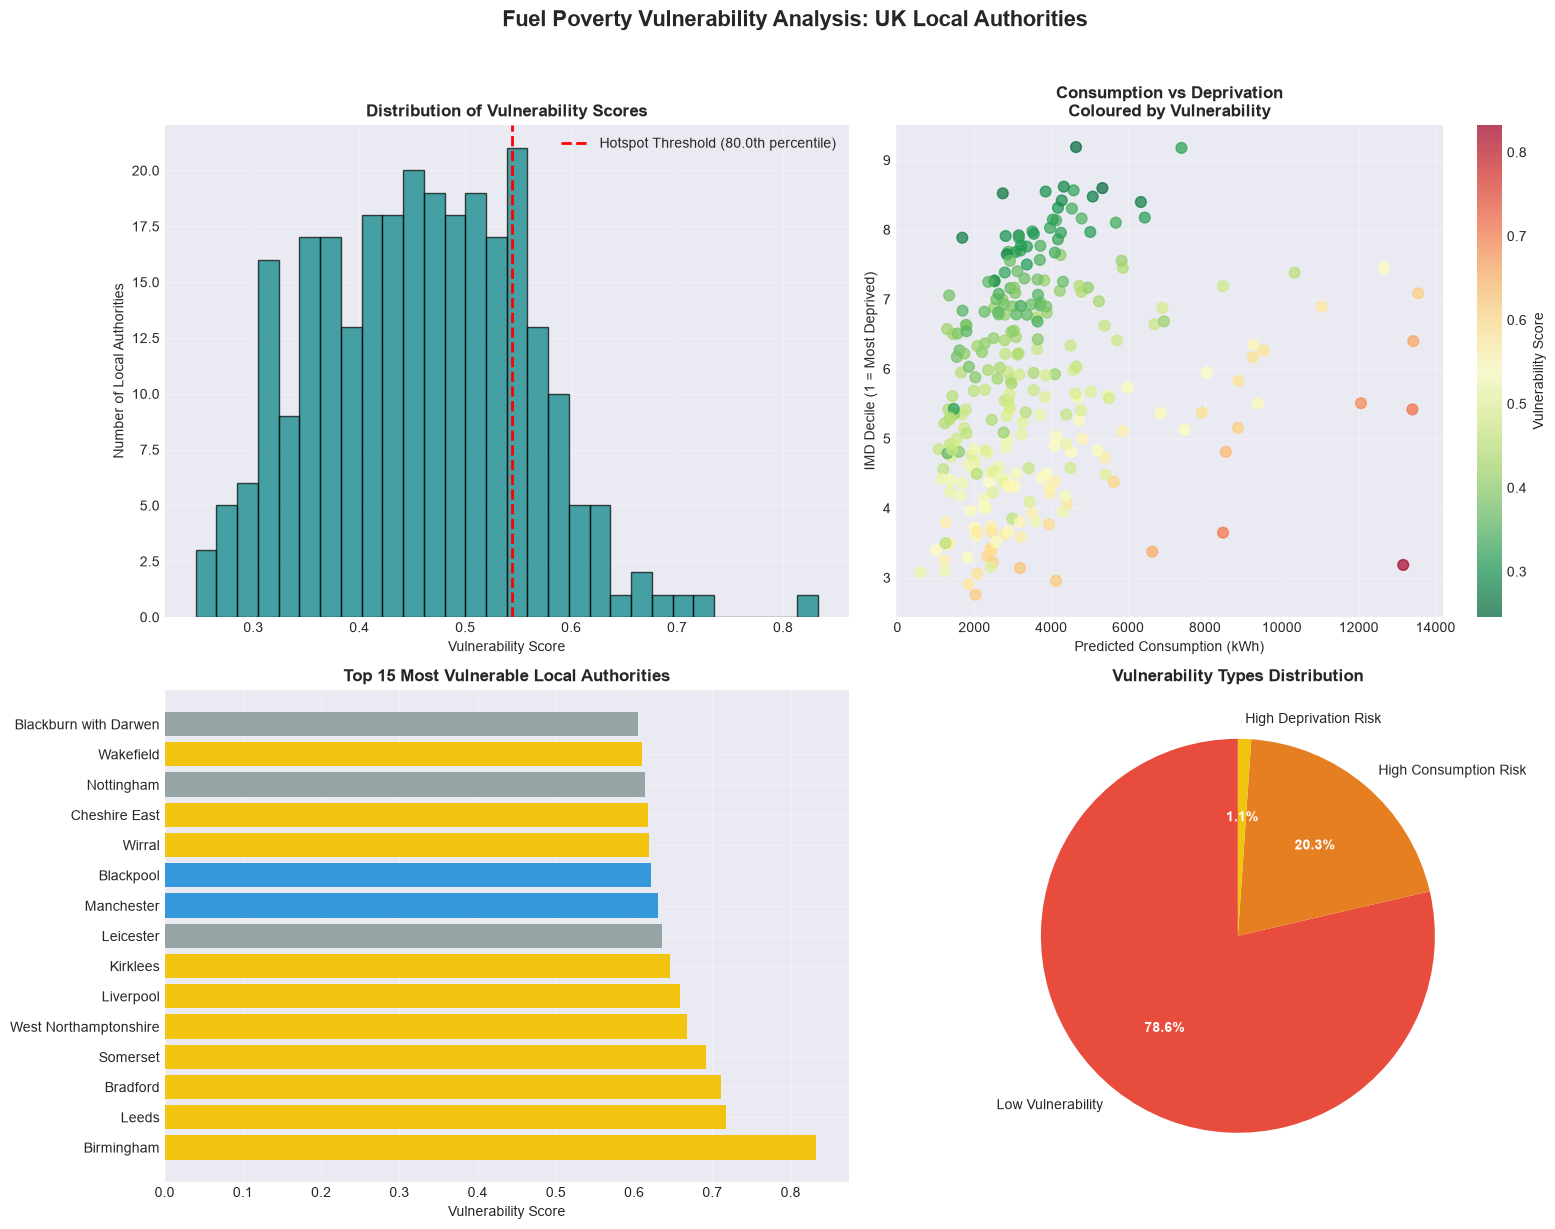


 POLICY RECOMMENDATIONS

 Vulnerability Profile Summary:
   o Critical Fuel Poverty: 0 areas
   o Fuel Poverty: 0 areas
   o High Consumption Risk: 56 areas
   o High Deprivation Risk: 3 areas

 HIGH CONSUMPTION RISK (56 areas)
   -> Requires ENERGY EFFICIENCY focus
   -> Example areas: Northumberland, Stockton-on-Tees, Newcastle upon Tyne
   -> Key Characteristics:
       o Avg Consumption: 7215 kWh
       o Avg IMD Decile: 6.28
   -> Recommended Interventions:
       o Energy efficiency audits
       o Insulation and heating upgrades
       o Behavioural change programmes
       o Time-of-use pricing incentives
   ____DO NOTE THAT THIS IS BASED ON LAYPERSON ADVICE AND MAY DIFFER FROM THE EXPERT ADVICE___ 

 HIGH DEPRIVATION RISK (3 areas)
   -> Requires FINANCIAL SUPPORT focus
   -> Example areas: Blackpool, Manchester, Hastings
   -> Key Characteristics:
       o Avg IMD Decile: 2.87
       o Avg Earnings: £646.1/week
   -> Recommended Interventions:
       o Expand fuel poverty su

In [40]:
# ============================================================================
# PART C: SYNTHESIS AND POLICY FRAMEWORK
# ============================================================================

print("\n" + "="*60)
print("PART C: SYNTHESIS AND POLICY FRAMEWORK")
print("="*60)

# Policy thresholds
HIGH_CONSUMPTION_QUANTILE = 0.8  # Top 20% consumers
LOW_EARNINGS_QUANTILE = 0.2      # Bottom 20% earners
VULNERABLE_IMD_THRESHOLD = 3     # IMD decile 3 or lower (most deprived)

# ============================================================================
# C.1 VULNERABILITY MAP CREATION
# ============================================================================

print("\n" + "="*60)
print("C.1 VULNERABILITY MAP CREATION")
print("="*60)

# Create vulnerability dataframe - using Merged_DF_2024 from Part A
vulnerability_df = Merged_DF_2024.copy()

# Add predictions - using XGB_Model from Part A
X_full_2024 = Merged_DF_2024[Feature_Columns]
X_full_2024_scaled = Scaler.transform(X_full_2024)
vulnerability_df['Predicted_Consumption'] = XGB_Model.predict(X_full_2024_scaled)
vulnerability_df['Actual_Consumption'] = vulnerability_df['LA1_Mean']

# Add price prediction from Part B
if 'XGB_Tuned_Pred' in locals():
    avg_predicted_price = np.mean(XGB_Tuned_Pred)
else:
    avg_predicted_price = 50
vulnerability_df['Predicted_Price'] = avg_predicted_price

# Identify vulnerability indicators
high_consumption_threshold = vulnerability_df['Predicted_Consumption'].quantile(HIGH_CONSUMPTION_QUANTILE)
vulnerability_df['High_Consumption'] = vulnerability_df['Predicted_Consumption'] >= high_consumption_threshold

vulnerability_df['High_Deprivation'] = vulnerability_df['IMD_Decile_Mean'] <= VULNERABLE_IMD_THRESHOLD

low_earnings_threshold = vulnerability_df['Earnings'].quantile(LOW_EARNINGS_QUANTILE)
vulnerability_df['Low_Earnings'] = vulnerability_df['Earnings'] <= low_earnings_threshold

# Create composite vulnerability score
def normalize(series):
    """Min-max normalize a series, handling edge cases"""
    if series.max() == series.min():
        return pd.Series(0.5, index=series.index)
    return (series - series.min()) / (series.max() - series.min())

vulnerability_df['Consumption_Score'] = normalize(vulnerability_df['Predicted_Consumption'])
vulnerability_df['Deprivation_Score'] = normalize(
    vulnerability_df['IMD_Decile_Mean'].max() - vulnerability_df['IMD_Decile_Mean']
)
vulnerability_df['Earnings_Score'] = normalize(
    vulnerability_df['Earnings'].max() - vulnerability_df['Earnings']
)
vulnerability_df['Price_Score'] = normalize(vulnerability_df['Predicted_Price'])

vulnerability_df['Vulnerability_Score'] = (
    vulnerability_df['Consumption_Score'] * 0.30 + 
    vulnerability_df['Deprivation_Score'] * 0.30 + 
    vulnerability_df['Earnings_Score'] * 0.20 +
    vulnerability_df['Price_Score'] * 0.20
)

vulnerability_df['Vulnerability_Score'] = pd.to_numeric(vulnerability_df['Vulnerability_Score'], errors='coerce')

# Identify hotspots
hotspot_threshold = vulnerability_df['Vulnerability_Score'].quantile(HIGH_CONSUMPTION_QUANTILE)
vulnerability_df['Hotspot'] = vulnerability_df['Vulnerability_Score'] >= hotspot_threshold

# Categorize vulnerabilities
vulnerability_df['Vulnerability_Type'] = 'Low Vulnerability'

# Type 1: Critical Fuel Poverty (High Consumption + High Deprivation + Low Earnings)
critical_mask = (
    vulnerability_df['High_Consumption'] & 
    vulnerability_df['High_Deprivation'] & 
    vulnerability_df['Low_Earnings']
)
vulnerability_df.loc[critical_mask, 'Vulnerability_Type'] = 'Critical Fuel Poverty'

# Type 2: Fuel Poverty (High Consumption + High Deprivation)
fuel_poverty_mask = (
    vulnerability_df['High_Consumption'] & 
    vulnerability_df['High_Deprivation'] &
    ~vulnerability_df['Low_Earnings']
)
vulnerability_df.loc[fuel_poverty_mask, 'Vulnerability_Type'] = 'Fuel Poverty'

# Type 3: High Consumption Risk
high_cons_mask = (
    vulnerability_df['High_Consumption'] & 
    ~vulnerability_df['High_Deprivation']
)
vulnerability_df.loc[high_cons_mask, 'Vulnerability_Type'] = 'High Consumption Risk'

# Type 4: High Deprivation Risk
high_dep_mask = (
    ~vulnerability_df['High_Consumption'] & 
    vulnerability_df['High_Deprivation']
)
vulnerability_df.loc[high_dep_mask, 'Vulnerability_Type'] = 'High Deprivation Risk'

vulnerability_df_clean = vulnerability_df.dropna(subset=['Vulnerability_Score'])

# ============================================================================
# C.1.1 Hotspot Statistics
# ============================================================================

print("\n" + "="*60)
print(" VULNERABILITY ANALYSIS RESULTS")
print("="*60)

print(f"\n Total Local Authorities Analysed: {len(vulnerability_df)}")

print(f"\n Thresholds Applied:")
print(f"   o High Consumption: Top 20% (> {high_consumption_threshold:.0f} kWh)")
print(f"   o High Deprivation: IMD Decile ≤ {VULNERABLE_IMD_THRESHOLD}")
print(f"   o Low Earnings: Bottom 20% (< £{low_earnings_threshold:.1f}/week)")

type_counts = vulnerability_df['Vulnerability_Type'].value_counts()
print(f"\n Vulnerability Types Identified:")
for v_type, count in type_counts.items():
    pct = count/len(vulnerability_df)*100
    print(f"   o {v_type}: {count} ({pct:.1f}%)")

print(f"\n Total Vulnerable Areas: {sum(vulnerability_df['Hotspot'])}")

# ============================================================================
# C.1.2 Top Vulnerable Areas
# ============================================================================

print("\n" + "="*60)
print(" TOP 15 MOST VULNERABLE LOCAL AUTHORITIES")
print("="*60)

if len(vulnerability_df_clean) > 0:
    top_vulnerable = vulnerability_df_clean.nlargest(15, 'Vulnerability_Score')[
        ['Area_Name', 'Predicted_Consumption', 'IMD_Decile_Mean', 'Earnings', 
         'Vulnerability_Score', 'Vulnerability_Type']
    ]
    print(top_vulnerable.round(2))

# ============================================================================
# C.1.3 Visualise Vulnerability Map
# ============================================================================

print("\n Creating Vulnerability Visualisations...")

plot_df = vulnerability_df_clean.copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Figure 1: Vulnerability Score Distribution
ax1 = axes[0, 0]
if len(plot_df) > 0:
    plot_df['Vulnerability_Score'].hist(bins=30, ax=ax1, color='teal', edgecolor='black', alpha=0.7)
    ax1.axvline(hotspot_threshold, color='red', linestyle='--', linewidth=2, 
                label=f'Hotspot Threshold ({HIGH_CONSUMPTION_QUANTILE*100}th percentile)')
    ax1.set_title('Distribution of Vulnerability Scores', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Vulnerability Score', fontsize=10)
    ax1.set_ylabel('Number of Local Authorities', fontsize=10)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

# Figure 2: Consumption vs Deprivation Scatter
ax2 = axes[0, 1]
if len(plot_df) > 0:
    scatter = ax2.scatter(plot_df['Predicted_Consumption'], 
                          plot_df['IMD_Decile_Mean'],
                          c=plot_df['Vulnerability_Score'],
                          cmap='RdYlGn_r',
                          alpha=0.7,
                          s=60)
    ax2.set_xlabel('Predicted Consumption (kWh)', fontsize=10)
    ax2.set_ylabel('IMD Decile (1 = Most Deprived)', fontsize=10)
    ax2.set_title('Consumption vs Deprivation\nColoured by Vulnerability', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=ax2, label='Vulnerability Score')
    ax2.grid(True, alpha=0.3)

# Figure 3: Top 15 Vulnerable Areas
ax3 = axes[1, 0]
if len(plot_df) > 0:
    top_hotspots = plot_df.nlargest(15, 'Vulnerability_Score')
    colors = ['#E74C3C' if x == 'Critical Fuel Poverty' else 
              '#E67E22' if x == 'Fuel Poverty' else
              '#F1C40F' if x == 'High Consumption Risk' else
              '#3498DB' if x == 'High Deprivation Risk' else '#95A5A6' 
              for x in top_hotspots['Vulnerability_Type']]
    bars = ax3.barh(top_hotspots['Area_Name'], top_hotspots['Vulnerability_Score'], color=colors)
    ax3.set_xlabel('Vulnerability Score', fontsize=10)
    ax3.set_title('Top 15 Most Vulnerable Local Authorities', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)

# Figure 4: Vulnerability Type Distribution
ax4 = axes[1, 1]
type_counts = plot_df['Vulnerability_Type'].value_counts()
colors_pie = ['#E74C3C', '#E67E22', '#F1C40F', '#3498DB', '#95A5A6']
if len(type_counts) > 1:
    patches, texts, autotexts = ax4.pie(type_counts.values, 
                                        labels=type_counts.index, 
                                        autopct='%1.1f%%',
                                        startangle=90,
                                        colors=colors_pie[:len(type_counts)])
    ax4.set_title('Vulnerability Types Distribution', fontsize=12, fontweight='bold')
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')

plt.suptitle('Fuel Poverty Vulnerability Analysis: UK Local Authorities', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('vulnerability_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# C.2 POLICY RECOMMENDATIONS
# ============================================================================

print("\n" + "="*60)
print(" POLICY RECOMMENDATIONS")
print("="*60)

# Get vulnerable areas by type
critical = vulnerability_df[vulnerability_df['Vulnerability_Type'] == 'Critical Fuel Poverty']
fuel_poverty = vulnerability_df[vulnerability_df['Vulnerability_Type'] == 'Fuel Poverty']
high_cons = vulnerability_df[vulnerability_df['Vulnerability_Type'] == 'High Consumption Risk']
high_dep = vulnerability_df[vulnerability_df['Vulnerability_Type'] == 'High Deprivation Risk']

print(f"\n Vulnerability Profile Summary:")
print(f"   o Critical Fuel Poverty: {len(critical)} areas")
print(f"   o Fuel Poverty: {len(fuel_poverty)} areas")
print(f"   o High Consumption Risk: {len(high_cons)} areas")
print(f"   o High Deprivation Risk: {len(high_dep)} areas")

# Policy Recommendations by Type
if len(critical) > 0:
    print(f"\n CRITICAL FUEL POVERTY ({len(critical)} areas)")
    print(f"   -> Requires IMMEDIATE intervention")
    print(f"   -> Example areas: {', '.join(critical['Area_Name'].tolist()[:3])}")
    print(f"   -> Key Characteristics:")
    print(f"       o Avg Consumption: {critical['Predicted_Consumption'].mean():.0f} kWh")
    print(f"       o Avg IMD Decile: {critical['IMD_Decile_Mean'].mean():.2f}")
    print(f"       o Avg Earnings: £{critical['Earnings'].mean():.1f}/week")
    print(f"   -> Recommended Interventions:")
    print(f"       o PRIORITY: Comprehensive energy efficiency retrofitting")
    print(f"       o PRIORITY: Fuel bill subsidies and payment support")
    print(f"       o Install smart heating controls and monitoring")
    print(f"       o Community energy advice services")
    print(f"   ____DO NOTE THAT THIS IS BASED ON LAYPERSON ADVICE AND MAY DIFFER FROM THE EXPERT ADVICE___ ")

if len(fuel_poverty) > 0:
    print(f"\n FUEL POVERTY ({len(fuel_poverty)} areas)")
    print(f"   -> Requires URGENT intervention")
    print(f"   -> Example areas: {', '.join(fuel_poverty['Area_Name'].tolist()[:3])}")
    print(f"   -> Key Characteristics:")
    print(f"       o Avg Consumption: {fuel_poverty['Predicted_Consumption'].mean():.0f} kWh")
    print(f"       o Avg IMD Decile: {fuel_poverty['IMD_Decile_Mean'].mean():.2f}")
    print(f"       o Avg Earnings: £{fuel_poverty['Earnings'].mean():.1f}/week")
    print(f"   -> Recommended Interventions:")
    print(f"       o Priority energy efficiency improvements")
    print(f"       o Targeted fuel bill support")
    print(f"       o Smart meter installation")
    print(f"       o Community energy programmes")
    print(f"   ____DO NOTE THAT THIS IS BASED ON LAYPERSON ADVICE AND MAY DIFFER FROM THE EXPERT ADVICE___ ")

if len(high_cons) > 0:
    print(f"\n HIGH CONSUMPTION RISK ({len(high_cons)} areas)")
    print(f"   -> Requires ENERGY EFFICIENCY focus")
    print(f"   -> Example areas: {', '.join(high_cons['Area_Name'].tolist()[:3])}")
    print(f"   -> Key Characteristics:")
    print(f"       o Avg Consumption: {high_cons['Predicted_Consumption'].mean():.0f} kWh")
    print(f"       o Avg IMD Decile: {high_cons['IMD_Decile_Mean'].mean():.2f}")
    print(f"   -> Recommended Interventions:")
    print(f"       o Energy efficiency audits")
    print(f"       o Insulation and heating upgrades")
    print(f"       o Behavioural change programmes")
    print(f"       o Time-of-use pricing incentives")
    print(f"   ____DO NOTE THAT THIS IS BASED ON LAYPERSON ADVICE AND MAY DIFFER FROM THE EXPERT ADVICE___ ")

if len(high_dep) > 0:
    print(f"\n HIGH DEPRIVATION RISK ({len(high_dep)} areas)")
    print(f"   -> Requires FINANCIAL SUPPORT focus")
    print(f"   -> Example areas: {', '.join(high_dep['Area_Name'].tolist()[:3])}")
    print(f"   -> Key Characteristics:")
    print(f"       o Avg IMD Decile: {high_dep['IMD_Decile_Mean'].mean():.2f}")
    print(f"       o Avg Earnings: £{high_dep['Earnings'].mean():.1f}/week")
    print(f"   -> Recommended Interventions:")
    print(f"       o Expand fuel poverty support programmes")
    print(f"       o Increase energy bill subsidies")
    print(f"       o Emergency fuel payment assistance")
    print(f"       o Community organisation partnerships")
    print(f"   ____DO NOTE THAT THIS IS BASED ON LAYPERSON ADVICE AND MAY DIFFER FROM THE EXPERT ADVICE___ ")

# ============================================================================
# C.2.1 Impact Analysis
# ============================================================================

print("\n" + "="*60)
print(" IMPACT ANALYSIS")
print("="*60)

total_vulnerable = len(vulnerability_df[vulnerability_df['Hotspot']])
if total_vulnerable > 0:
    vulnerable_areas = vulnerability_df[vulnerability_df['Hotspot']]
    avg_consumption_vul = vulnerable_areas['Predicted_Consumption'].mean()
    avg_consumption_all = vulnerability_df['Predicted_Consumption'].mean()
    
    potential_reduction = 0.15
    total_savings = avg_consumption_vul * potential_reduction * total_vulnerable
    
    print(f"\n Estimated Impact of Targeted Interventions:")
    print(f"   o Total vulnerable areas: {total_vulnerable}")
    print(f"   o Avg consumption (vulnerable): {avg_consumption_vul:.0f} kWh")
    print(f"   o Avg consumption (all areas): {avg_consumption_all:.0f} kWh")
    print(f"   o Estimated annual savings: {total_savings:,.0f} kWh")
    print(f"   o Carbon reduction: {total_savings * 0.2:,.0f} kg CO2/year")

# Save results
vulnerability_df.to_csv('fuel_poverty_hotspots.csv', index=False)
print("\nV Vulnerability data saved to 'fuel_poverty_hotspots.csv'")

if total_vulnerable > 0:
    vulnerable_areas.to_csv('fuel_poverty_hotspots_identified.csv', index=False)
    print("V Hotspot areas saved to 'fuel_poverty_hotspots_identified.csv'")


## C.2 Vulnerability Map Using Boundaries



 CREATING UK VULNERABILITY MAP

 Loading Local Authority boundaries...
V Loaded 361 Local Authorities
V Loaded 276 vulnerability records
 Using 'LAD24NM' for area names

 Generating maps...


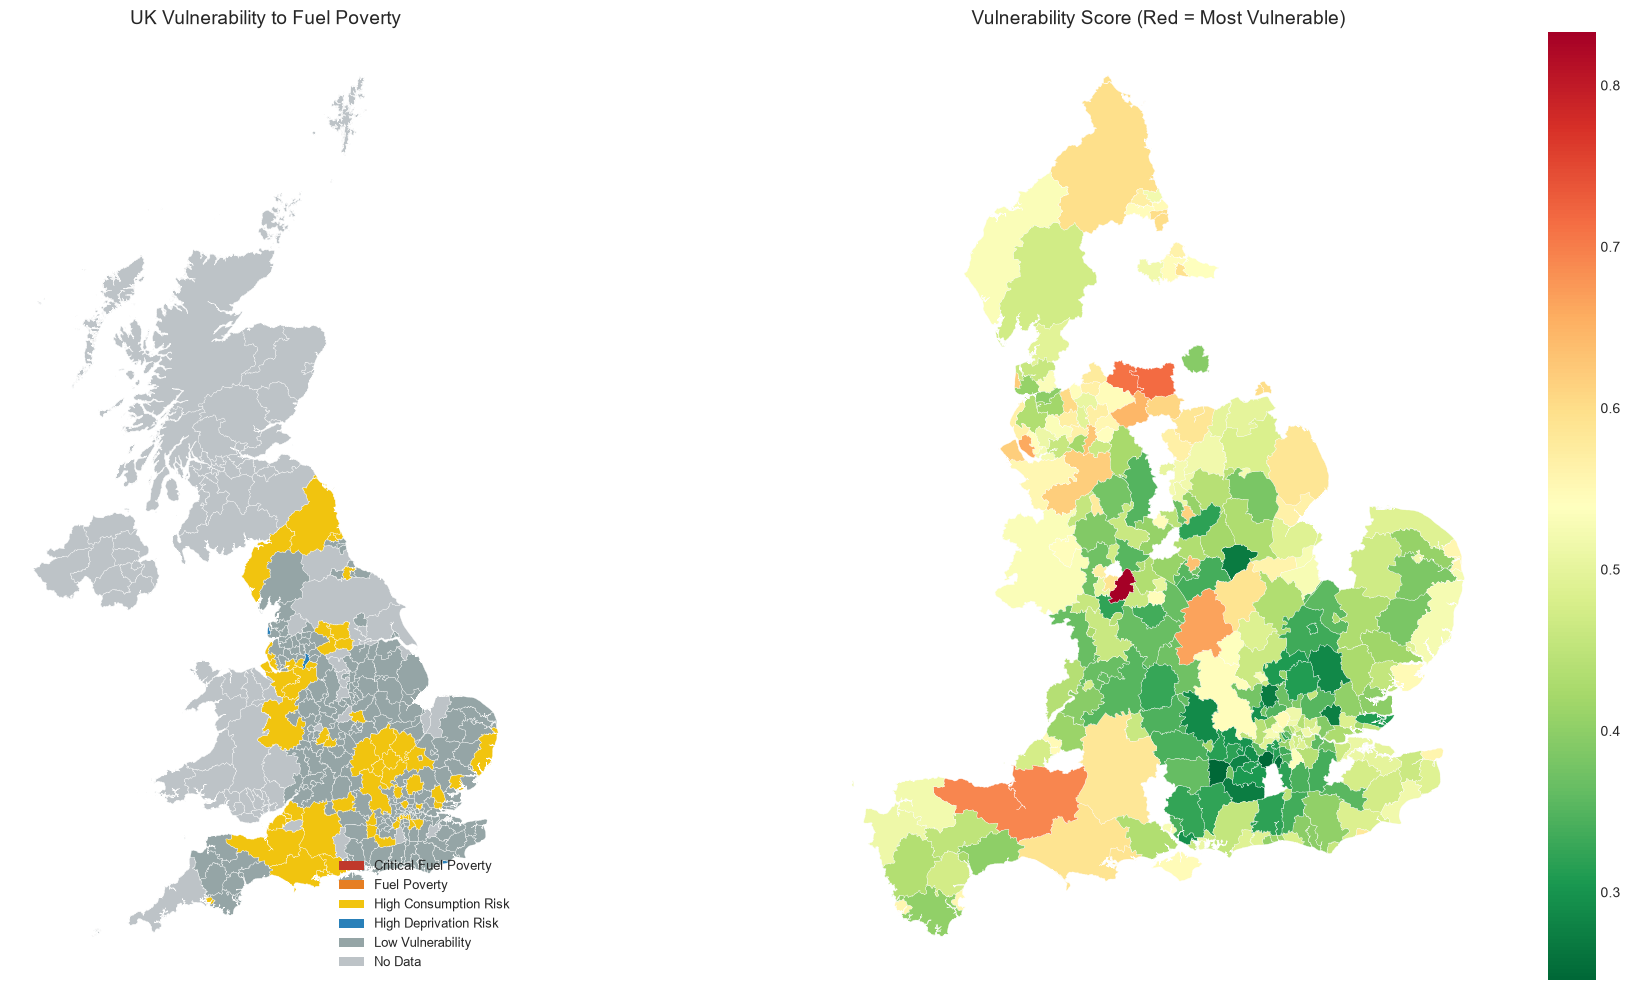

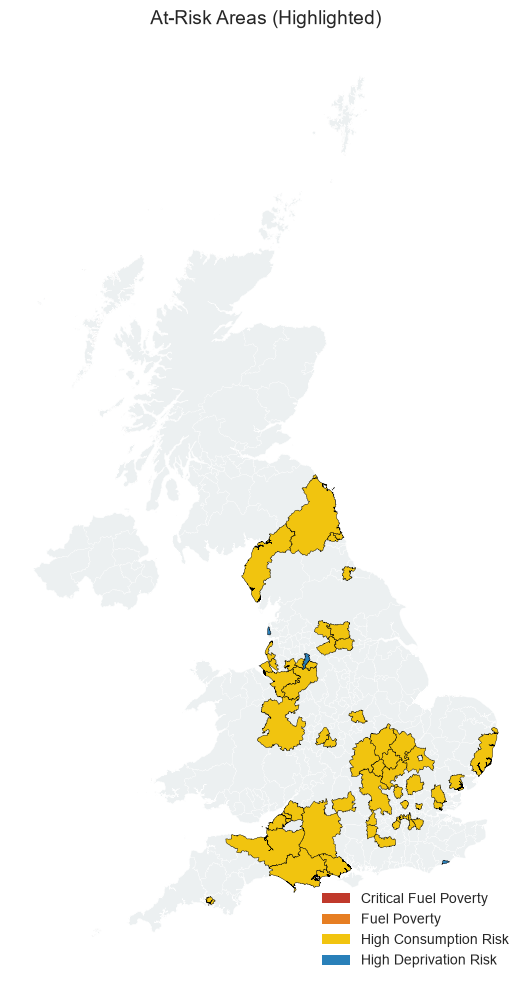

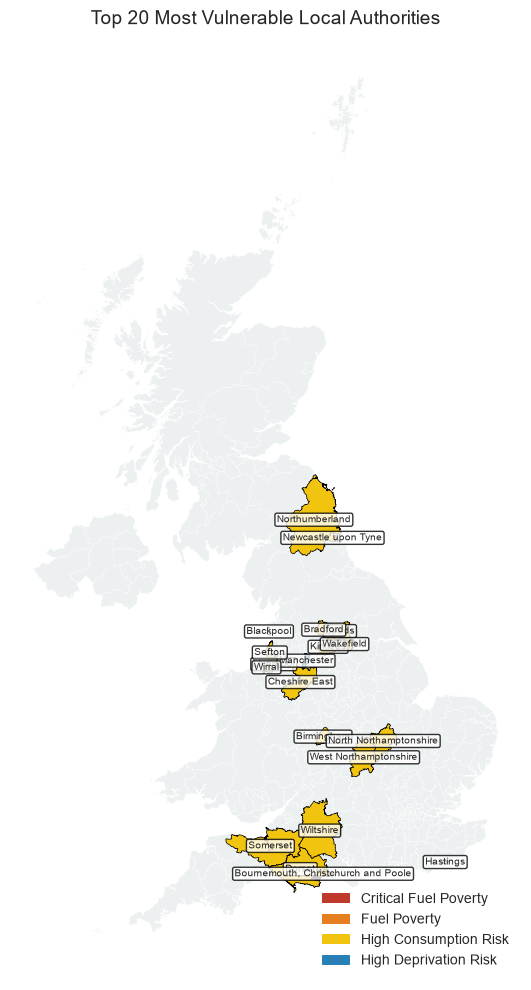

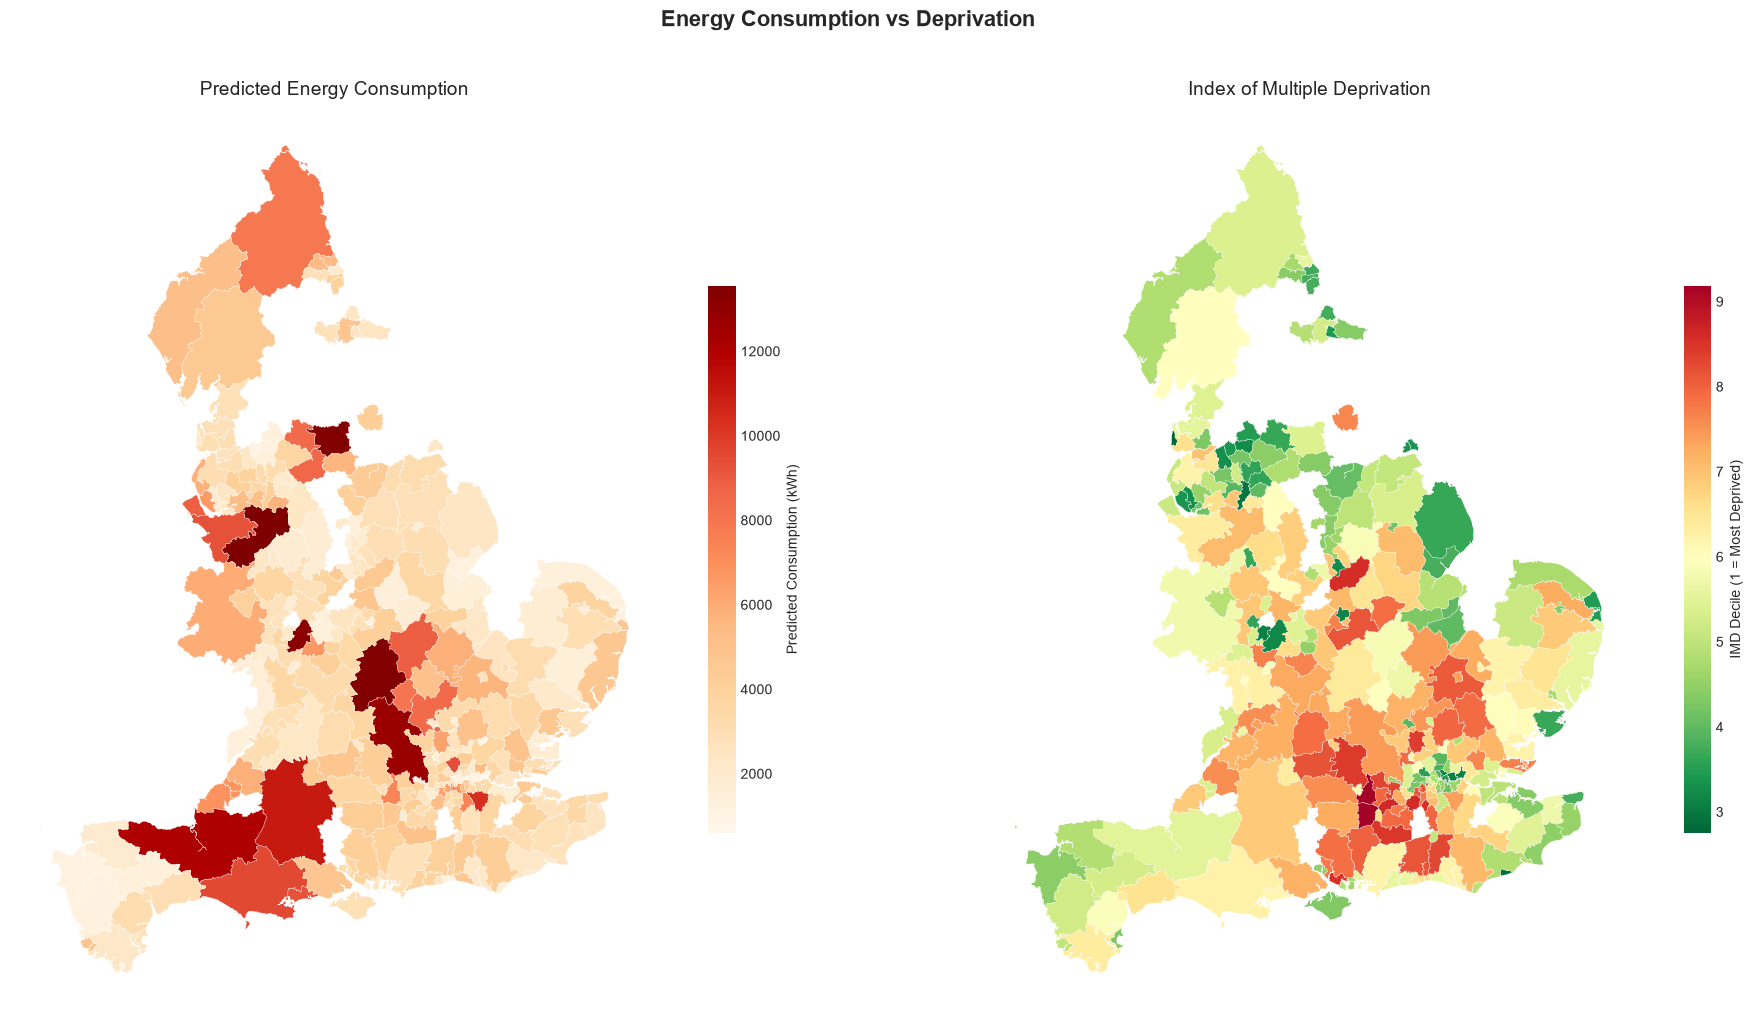


 SUMMARY
Low Vulnerability: 217 (60.1%)
No Data: 85 (23.5%)
High Consumption Risk: 56 (15.5%)
High Deprivation Risk: 3 (0.8%)

V Maps saved as PNG files


In [51]:
# ============================================================================
# UK VULNERABILITY MAP
# ============================================================================

print("\n" + "="*60)
print(" CREATING UK VULNERABILITY MAP")
print("="*60)

# ============================================================================
# 1. LOAD DATA
# ============================================================================

print("\n Loading Local Authority boundaries...")

# Load your shapefile
shapefile_path = "C:/Users/Rizky Fathur Insan/OneDrive/Documents/schoolwork/boundaries/LAD_DEC_24_UK_BFC.shp"
boundaries = gpd.read_file(shapefile_path)
print(f"V Loaded {len(boundaries)} Local Authorities")

# Load vulnerability data
map_df = pd.read_csv('fuel_poverty_hotspots.csv')
print(f"V Loaded {len(map_df)} vulnerability records")

# ============================================================================
# 2. PREPARE AND MERGE
# ============================================================================

# Clean data for merging
map_df['Area_Name'] = map_df['Area_Name'].astype(str).str.strip()

# Find the name column in shapefile
name_col = [col for col in boundaries.columns if 'NM' in col][0]
print(f" Using '{name_col}' for area names")

# Clean area names in boundaries
boundaries['Area_Clean'] = boundaries[name_col].astype(str).str.strip()

# Merge
uk_map = boundaries.merge(map_df, left_on='Area_Clean', right_on='Area_Name', how='left')

# Define vulnerability colors
colors = {
    'Critical Fuel Poverty': '#C0392B',
    'Fuel Poverty': '#E67E22', 
    'High Consumption Risk': '#F1C40F',
    'High Deprivation Risk': '#2980B9',
    'Low Vulnerability': '#95A5A6'
}

uk_map['Vulnerability_Type'] = uk_map['Vulnerability_Type'].fillna('No Data')
uk_map['Color'] = uk_map['Vulnerability_Type'].apply(lambda x: colors.get(x, '#BDC3C7'))

# ============================================================================
# 3. CREATE MAPS
# ============================================================================

print("\n Generating maps...")

# Map 1: Full UK Map
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Vulnerability types
uk_map.plot(ax=ax1, color=uk_map['Color'], edgecolor='white', linewidth=0.2)
ax1.set_title('UK Vulnerability to Fuel Poverty', fontsize=14)
ax1.set_axis_off()

# Legend
legend_elements = [mpatches.Patch(facecolor=c, label=t) for t, c in colors.items()]
legend_elements.append(mpatches.Patch(facecolor='#BDC3C7', label='No Data'))
ax1.legend(handles=legend_elements, loc='lower right', fontsize=9)

# Vulnerability score heatmap
uk_map.plot(ax=ax2, column='Vulnerability_Score', cmap='RdYlGn_r', 
           edgecolor='white', linewidth=0.2, legend=True)
ax2.set_title('Vulnerability Score (Red = Most Vulnerable)', fontsize=14)
ax2.set_axis_off()

plt.tight_layout()
plt.savefig('uk_vulnerability_map.png', dpi=300, bbox_inches='tight')
plt.show()

# Map 2: Focused Vulnerable Areas (show only at-risk)
fig, ax = plt.subplots(figsize=(16, 10))

# All areas in grey
uk_map.plot(ax=ax, color='#ECF0F1', edgecolor='white', linewidth=0.2)

# Overlay vulnerable areas
vulnerable = uk_map[~uk_map['Vulnerability_Type'].isin(['Low Vulnerability', 'No Data'])]
if len(vulnerable) > 0:
    vulnerable.plot(ax=ax, color=vulnerable['Color'], edgecolor='black', linewidth=0.3)

ax.set_title('At-Risk Areas (Highlighted)', fontsize=14)
ax.set_axis_off()

# Legend
legend_elements = [mpatches.Patch(facecolor=c, label=t) for t, c in colors.items() 
                   if t != 'Low Vulnerability']
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('uk_vulnerable_areas.png', dpi=300, bbox_inches='tight')
plt.show()

# Map 3: Top 20 vulnerable areas with labels
if len(vulnerable) > 0:
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Base map
    uk_map.plot(ax=ax, color='#ECF0F1', edgecolor='white', linewidth=0.2)
    
    # Top 20
    top20 = vulnerable.nlargest(20, 'Vulnerability_Score')
    top20.plot(ax=ax, color=top20['Color'], edgecolor='black', linewidth=0.5)
    
    # Add labels
    for idx, row in top20.iterrows():
        if not row.geometry.is_empty:
            centroid = row.geometry.centroid
            ax.annotate(row[name_col], (centroid.x, centroid.y), 
                       fontsize=7, ha='center', va='center',
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
    
    ax.set_title('Top 20 Most Vulnerable Local Authorities', fontsize=14)
    ax.set_axis_off()
    
    legend_elements = [mpatches.Patch(facecolor=c, label=t) for t, c in colors.items() 
                       if t != 'Low Vulnerability']
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('uk_top20_vulnerable.png', dpi=300, bbox_inches='tight')
    plt.show()

# Map 4: Consumption vs Deprivation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Predicted consumption
uk_map.plot(ax=ax1, column='Predicted_Consumption', cmap='OrRd', 
           edgecolor='white', linewidth=0.2, legend=True,
           legend_kwds={'label': 'Predicted Consumption (kWh)', 'shrink': 0.6})
ax1.set_title('Predicted Energy Consumption', fontsize=14)
ax1.set_axis_off()

# IMD Deprivation
uk_map.plot(ax=ax2, column='IMD_Decile_Mean', cmap='RdYlGn_r', 
           edgecolor='white', linewidth=0.2, legend=True,
           legend_kwds={'label': 'IMD Decile (1 = Most Deprived)', 'shrink': 0.6})
ax2.set_title('Index of Multiple Deprivation', fontsize=14)
ax2.set_axis_off()

plt.suptitle('Energy Consumption vs Deprivation', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('uk_consumption_deprivation.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 4. SUMMARY STATISTICS
# ============================================================================

print("\n SUMMARY")
print("="*40)
type_counts = uk_map['Vulnerability_Type'].value_counts()
for vtype, count in type_counts.items():
    pct = count/len(uk_map)*100
    print(f"{vtype}: {count} ({pct:.1f}%)")

print(f"\nV Maps saved as PNG files")

## Notebook Summary
